<a href="https://colab.research.google.com/github/binh-nguyen12/binh-nguyen12.github.io/blob/main/Kahana_Feld_Sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS145: Project 2 | What's In a Name? The Socioeconomics of Baby Names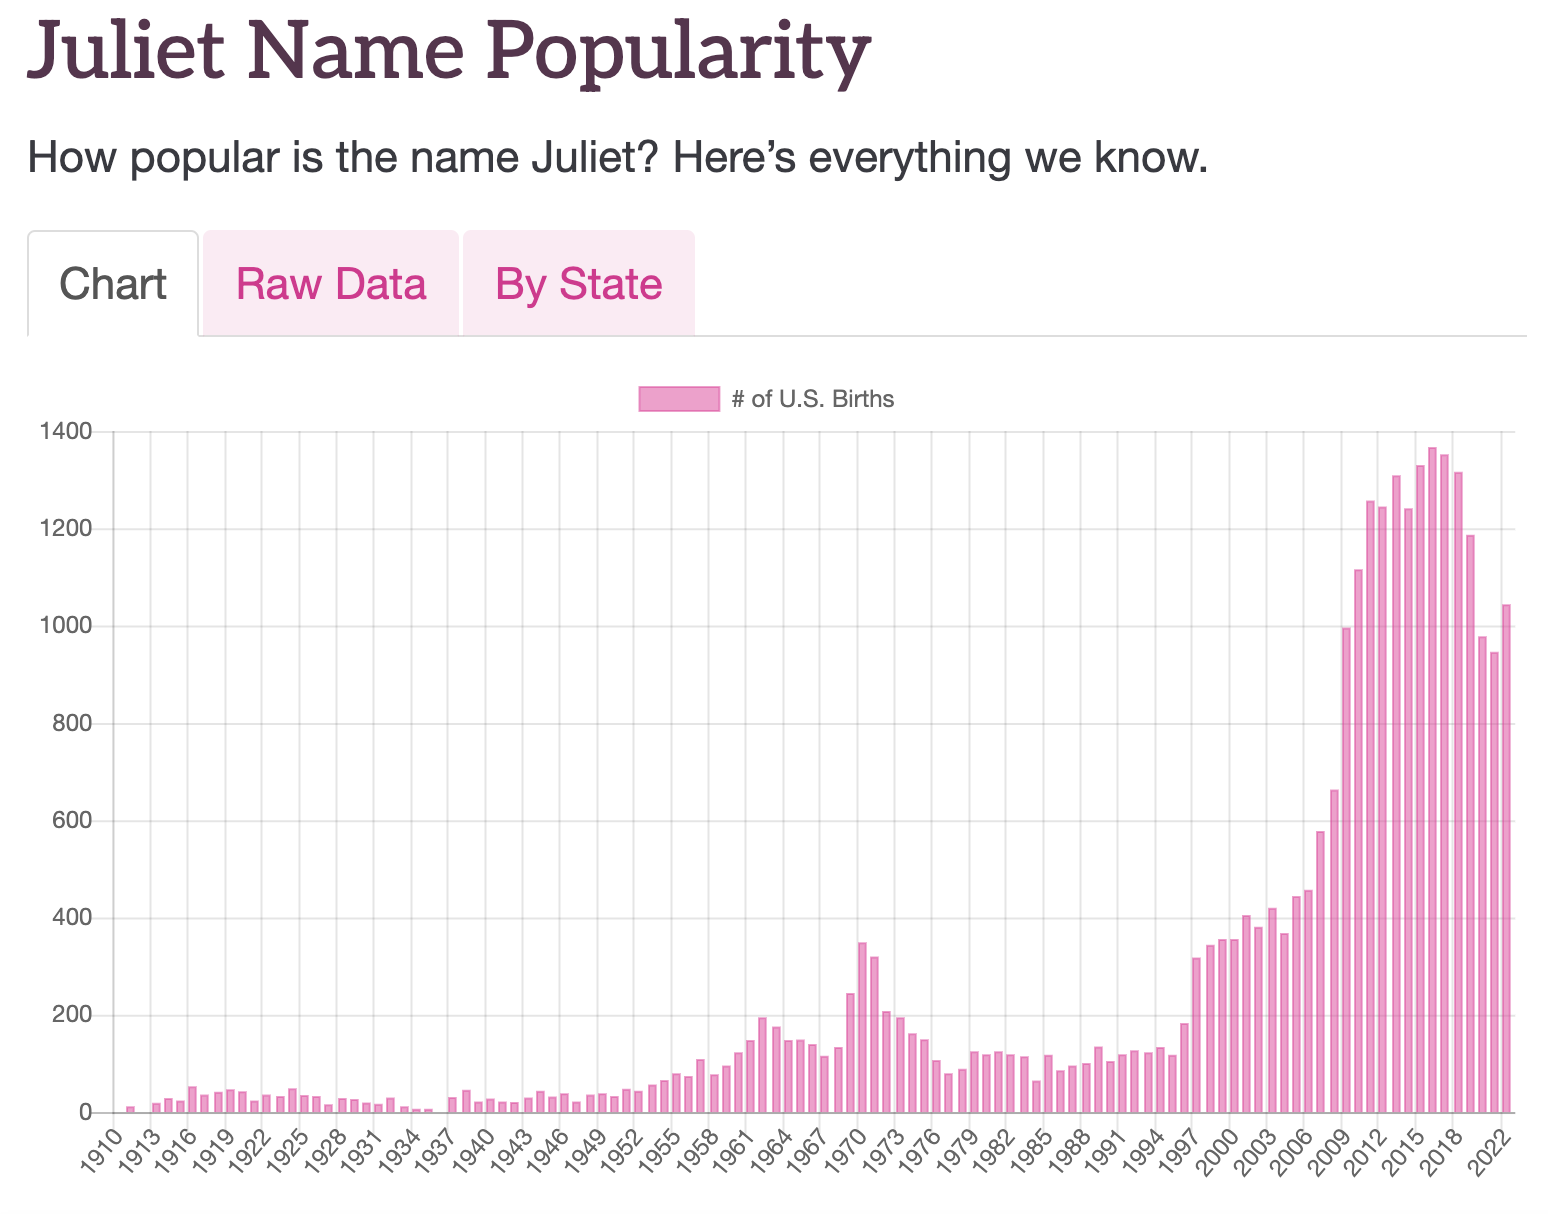

## Collaborators:
Please list the names and SUNet IDs of your collaborators below:
* *Binh, btn1229*

## Project Overview

---

What influences the cycle of first names? Despite what Shakespeare's Juliet will tell you, a rose may smell just as sweet if it was called a daffodil, but there wouldn't be nearly as many girls named after it. The irony behind her famed speech is that the name Juliet would spike in popularity twice in the twentiesth century following the release of two major film adaptations. Can you quess roughly which years those movies came out? Have a look at the graph displayed above.

In this project, we wanted to focus on the socioeconomic factors influencing the naming of babies across regions. How do naming practices shed light on the people who give them?

To answer these questions, we will be looking at two main datasets available publicly on bigquery. The first one is the USA Names dataset from the Social Security Administration, which contains all the names from social security card applications for births that occurred in the United States after 1879. It's a rich resource for insight on naming trends by region and by year, and though it is small, it will be the central dataset for our project.

Our secondary source is the American Community Survey, which contains extremely detailed yearly demographical information, from which we can extract potential indicators for naming trends. The bulk of this project will focus on the diversity of names—specifically, the etymological diversity of names across the United States—and on identifying which socioeconomic indicators influence these trends.

To delve into the meaning of names, we will also be using a smaller dataset that contains information on the origin of names.

---


## Analysis of Dataset

---

Let's first take a look at our various datasets.

The usa_names dataset is a fairly small dataset containing the number of applicants for a Social Security card by year, name, date of birth, gender, and state. From this dataset, we can get insight on how many babies are born per year and per state with any given name. Because it spans over 100 years and all 50 states, we have a good amount to play with. There is only one table within the dataset that we will be using. bigquery-public-data.usa_names.usa_1910_current is the most recent of the two available in the dataset, spanning 1910 to 2021. At around 185.85 MB, it is fairly small but comprehensive. The columns are:

**state**: STRING, 2-digit state code

**gender:** STRING, 'F' or 'M'

**year:** INT, the year the ssc was registered

**name:** STRING, the given name of that person

**number:** INT, number of occurrences of the name

The census_bureau_acs dataset is a very large dataset containing extremely detailed demographical information across regions in the United States. This dataset was a lot to parse through, and was by far the best recourse for looking at social and economic information at a granular level. The tables we will be using are all the available state_[year]_1yr tables, spanning 2007 to 2021, skipping 2020. The tables range from 100 to 250KB and contain way too many columns to list here. Below are some select columns we will be using in our research.

**geo_id:** STRING, state fips code

**median_income:** FLOAT, median household income in the past 12 Months

**bachelors_degree_or_higher_25_64:** FLOAT, the number of people in each geography who are between the ages of 25 and 64 who have attained a bachelors degree or higher.

**households_public_asst_or_food_stamps:** FLOAT, households on cash public assistance or receiving food stamps

The behind_the_name dataset was created by Mohamed Anwar on github, (https://github.com/Anwarvic/Behind-The-Name/blob/master/dataset3.csv). All of the names and their origins were extracted by Anwar from the website Behind_The_Name. In the project, we will be cloning it to use in our analysis. The data table (cloned) is 26.18 MB. We will be using it to map the names from the usa_names dataset to its origins. Notable columns are:

**name:** STRING, the name

**origin:** STRING, a list of origins of all of the names

**gender:** STRING, the gender of the name, 'm', 'f' or 'm&f'

Between these 3 datasets, we have a lot to work with. Though there is a small temporal exploration of the datasets at the beginning, we cannot look at the full scope of the names from the usa_names dataset like we originally wanted to since the ACS only contains data from 2007 to 2021. That would've been a much richer analysis of the nature of naming trends. Another issue we ran into is that the behind_the_name dataset maps many origins to 1 name, since the history and etymology of a name gets so complicated. Due to this, the data may be cloudy, as it can be hard to guage the true "origin" of a name with so many. However, this might be to our benefit, since it may not be practical to think about names on such a deep level when you're dealing with an entire population. It may be just as well that the name 'Sarah', which is technically hebrew, is listed as english, french, and many others. We had a lot of fun looking at potential indicators. The one gripe we had about the ACS dataset is that there is no table to map geo_id to the region name. Because of this, we had to rely on an external table to map the fips code to the state code. Despite all this, there is a lot to uncover between these datasets. Let's take a look.

----

## Data Exploration

For the first part of this exploration, we were just having fun looking at trends across time and region within the usa_names dataset.

In [ ]:
# Run this cell to authenticate yourself to BigQuery
from google.colab import auth
auth.authenticate_user()
project_id = "bn-project-1-401808"

In [ ]:
# Initialize BiqQuery client
from google.cloud import bigquery
client = bigquery.Client(project=project_id)

Let's just first start by looking at the 10 most popular boy names of all time, by the total number of times a boy was born with that name.

In [ ]:
%%bigquery --project $project_id

SELECT name, gender, SUM(number) AS total
FROM bigquery-public-data.usa_names.usa_1910_current
WHERE gender = 'M'
GROUP BY name, gender
ORDER BY total DESC
LIMIT 10

Query is running:   0%|          |

Downloading:   0%|          |

,name,gender,total
0,James,M,5035762
1,John,M,4895305
2,Robert,M,4747986
3,Michael,M,4379257
4,William,M,3929698
5,David,M,3623306
6,Joseph,M,2548904
7,Richard,M,2545613
8,Charles,M,2291897
9,Thomas,M,2265071


Fairly predictable. Because we knew we wanted to look at the yearly rank of names a lot, we decided to make a separate table for it. The following query constructs a dataset called names_ranked and table for both girls and boys and assigns a rank to the names by year.

In [ ]:
%%bigquery --project $project_id

CREATE SCHEMA IF NOT EXISTS names_ranked;

-- Create the table for ranked girls' names
CREATE OR REPLACE TABLE names_ranked.girls_yearly AS
WITH yearly_ranked_girl_names AS (
  SELECT year, name, SUM(number) AS Total_Number_Yearly,
  ROW_NUMBER() OVER(
    PARTITION BY year
    ORDER BY SUM(number) DESC
  ) AS yearly_rank
  FROM `bigquery-public-data.usa_names.usa_1910_current`
  WHERE gender = 'F'
  GROUP BY year, name
)
SELECT year, 'F' as gender, name, Total_Number_Yearly, yearly_rank
FROM yearly_ranked_girl_names
WHERE yearly_rank <= 1000
ORDER BY year, yearly_rank;

-- Create the table for ranked boys' names
CREATE OR REPLACE TABLE names_ranked.boys_yearly AS
WITH yearly_ranked_boys_names AS (
  SELECT year, name, SUM(number) AS Total_Number_Yearly,
  ROW_NUMBER() OVER(
    PARTITION BY year
    ORDER BY SUM(number) DESC
  ) AS yearly_rank
  FROM `bigquery-public-data.usa_names.usa_1910_current`
  WHERE gender = 'M'
  GROUP BY year, name
)
SELECT year, 'M' as gender, name, Total_Number_Yearly, yearly_rank
FROM yearly_ranked_boys_names
WHERE yearly_rank <= 1000
ORDER BY year, yearly_rank;






Query is running:   0%|          |

""


Now let's take a look at this new table.

In [ ]:
%%bigquery --project $project_id

SELECT
  g.year,
  g.name AS girl,
  b.name AS boy
FROM
  names_ranked.girls_yearly AS g
FULL OUTER JOIN
  names_ranked.boys_yearly AS b
ON
  g.year = b.year
WHERE
  g.yearly_rank = 1
  AND b.yearly_rank = 1
ORDER BY
  g.year;




Query is running:   0%|          |

Downloading:   0%|          |

,year,girl,boy
0,1910,Mary,John
1,1911,Mary,John
2,1912,Mary,John
3,1913,Mary,John
4,1914,Mary,John
...,...,...,...
107,2017,Emma,Liam
108,2018,Emma,Liam
109,2019,Olivia,Liam
110,2020,Olivia,Liam


Again, fairly predictable. At first glance these all seem like very common english or romance language names. All of them are quite timeless. A fair number of them are biblical. Here are some queries for the most popular name by year and by decade.

In [ ]:
%%bigquery --project $project_id
WITH Boys AS (
  SELECT DIV(year, 10) * 10 AS decade, name,
    SUM(Total_Number_Yearly) as total
  FROM `names_ranked.boys_yearly`
  GROUP BY decade, name
),
Girls AS (
  SELECT DIV(year, 10) * 10 AS decade, name,
    SUM(Total_Number_Yearly) as total
  FROM `names_ranked.girls_yearly`
  GROUP BY decade, name
),
RankedBoys AS (
  SELECT decade, name,
  ROW_NUMBER() OVER (PARTITION BY decade ORDER BY total DESC) as rn
  FROM Boys
),
RankedGirls AS (
  SELECT decade, name,
  ROW_NUMBER() OVER (PARTITION BY decade ORDER BY total DESC) as rn
  FROM Girls
)
SELECT b.decade, b.name as Boy, g.name as Girl
FROM RankedBoys b
JOIN RankedGirls g
ON b.decade = g.decade AND b.rn = g.rn
WHERE b.rn = 1
ORDER BY b.decade



Query is running:   0%|          |

Downloading:   0%|          |

,decade,Boy,Girl
0,1910,John,Mary
1,1920,Robert,Mary
2,1930,Robert,Mary
3,1940,James,Mary
4,1950,James,Mary
5,1960,Michael,Lisa
6,1970,Michael,Jennifer
7,1980,Michael,Jessica
8,1990,Michael,Jessica
9,2000,Jacob,Emily


Now let's do fun things with this data!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

Let's visualize the number one ranked name for each gender.

In [ ]:
girls_query = """
SELECT year, name, Total_Number_Yearly
FROM names_ranked.girls_yearly
WHERE yearly_rank = 1
ORDER BY year;
"""

boys_query = """
SELECT year, name, Total_Number_Yearly
FROM names_ranked.boys_yearly
WHERE yearly_rank = 1
ORDER BY year;
"""

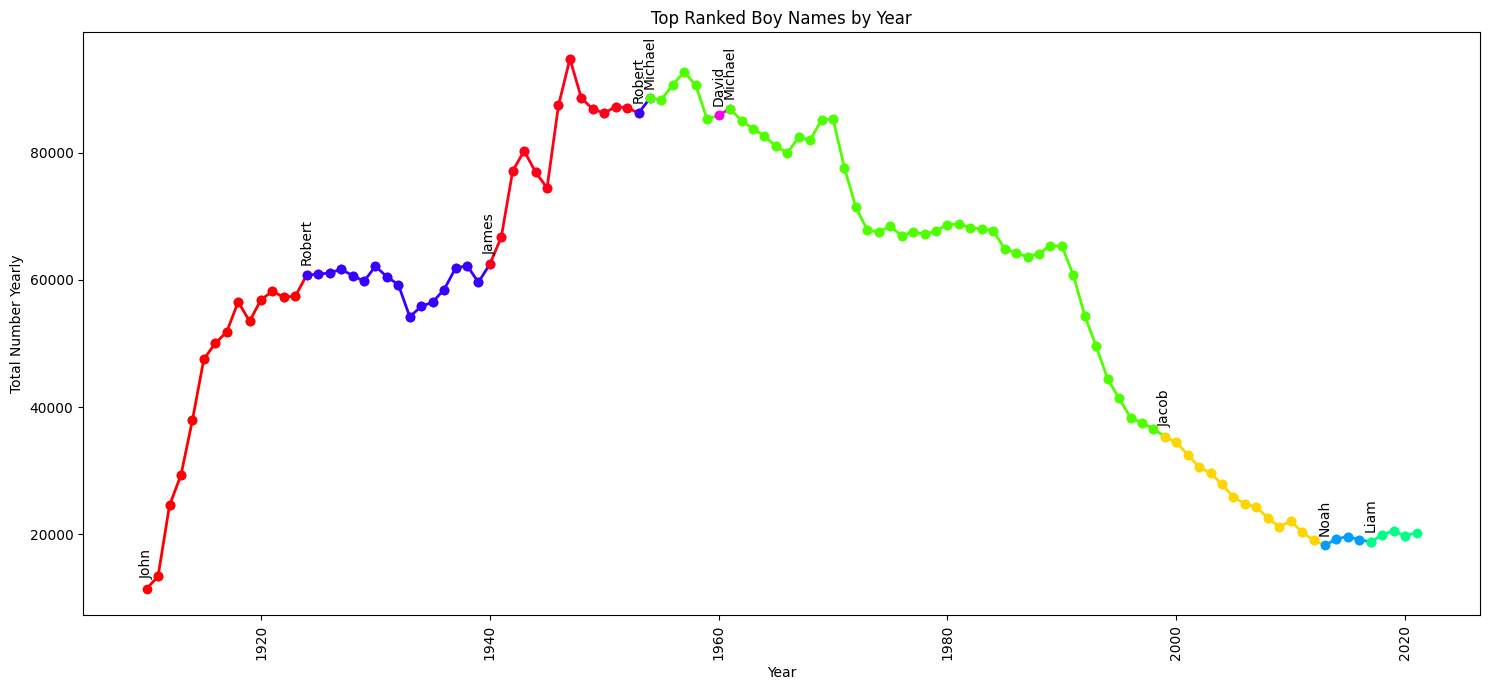

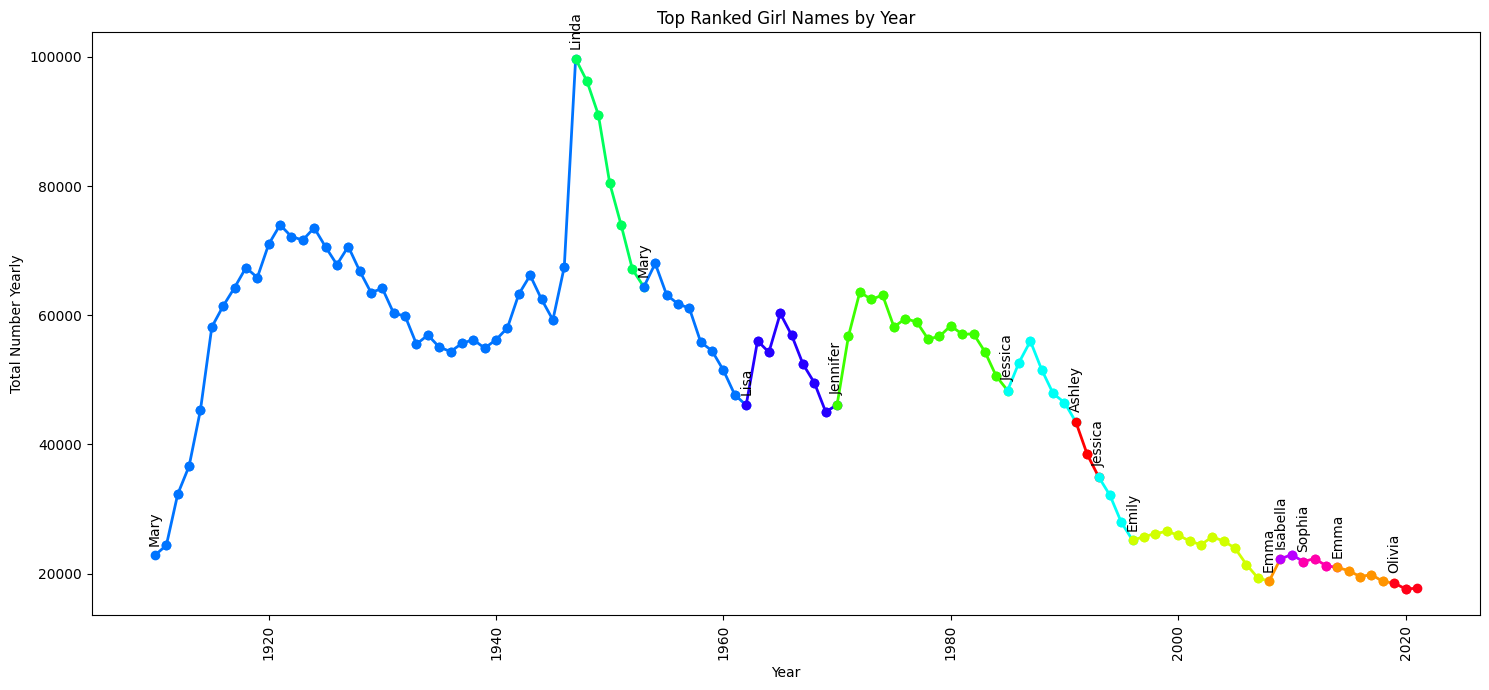

In [ ]:
girls_data = client.query(girls_query).result().to_dataframe()
boys_data = client.query(boys_query).result().to_dataframe()

# Function to get a unique color for each name
def get_unique_colors(names):
    unique_names = list(set(names))
    cmap = mcolors.ListedColormap(plt.cm.hsv(np.linspace(0, 1, len(unique_names))))
    return {name: cmap(i) for i, name in enumerate(unique_names)}

# Example usage of plot_data function

def plot_data(data, color_map, title, ax):

    last_name = None
    for i in range(len(data) - 1):
        current_name = data.iloc[i]['name']
        next_name = data.iloc[i + 1]['name']
        # Draw line segment
        ax.plot(data['year'][i:i+2], data['Total_Number_Yearly'][i:i+2],
                color=color_map[current_name], lw=2, marker='o')
        # If the name changes, draw a vertical line and add the name label
        if i == 0 or current_name != last_name:
            ax.text(data['year'][i],data['Total_Number_Yearly'][i]+ 1500, current_name,
                    verticalalignment='bottom', horizontalalignment='center',
                    fontsize=10, rotation=90)
        last_name = current_name
    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.set_ylabel('Total Number Yearly')

fig, ax = plt.subplots(figsize=(15, 7))
color_map_boys = get_unique_colors(boys_data['name'])

# Plotting boys data
plot_data(boys_data, color_map_boys, 'Top Ranked Boy Names by Year', ax)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(15, 7))
color_map_girls = get_unique_colors(girls_data['name'])

# Plotting girls data
plot_data(girls_data, color_map_girls, 'Top Ranked Girl Names by Year', ax)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Interesting. We see here that the name Mary endured for the better part of the 20th century. In addition, everyone probably has at least two boomer aunts named Linda. She's been married twice to a Robert and a James.

From these graphs, we can see why it's important to look at name popularity by year across a long period of time, which is why we focused on the rank of names per year rather than the total aggregate count of babies with that name over time. We see that in recent years, Olivia has been the the top ranked name. However, there aren't nearly as many babies named Olivia today as there are boomer aunts named Linda and Dads named Robert. This may be indicative of the increasing diversity of names over time.

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

In [ ]:

girl_query = """
WITH Distinct_Names AS (
    SELECT DISTINCT name
    FROM names_ranked.girls_yearly
    WHERE yearly_rank = 1
),
Year_Name_Matrix AS (
    SELECT y.year, n.name
    FROM (
        SELECT DISTINCT year
        FROM names_ranked.girls_yearly
    ) y
    CROSS JOIN Distinct_Names n
)
SELECT ynm.year, ynm.name,
       COALESCE(gy.yearly_rank, 1000) as yearly_rank
FROM Year_Name_Matrix ynm
LEFT JOIN names_ranked.girls_yearly gy
ON ynm.year = gy.year AND ynm.name = gy.name
ORDER BY ynm.year, ynm.name;
 """


In [ ]:

def plot_names_by_year(dataframe):
    fig = go.Figure()

    for name in dataframe['name'].unique():
        subset = dataframe[dataframe['name'] == name]
        fig.add_trace(go.Scatter(x=subset['year'], y=subset['yearly_rank'],
                                 mode='lines+markers',
                                 name=name,
                                 hoverinfo='x+y+name'))
    fig.update_layout(
        title='Rank of Names by Year',
        xaxis_title='Year',
        yaxis_title='Rank',
        yaxis=dict(autorange="reversed"),  # Reverse y-axis
        legend_title_text='Name'
    )

    fig.show()

Here is a graph of all of the top ranked names through the years and their popularity over time. It's interesting to see the names that shoot up from obscurity. In a different project, it may be quite interesting to look at how pop culture influences the tide of names, and what contributes to a name rapidly jumping up the ranks.

In [ ]:
girl_data = client.query(girl_query).result().to_dataframe()
plot_names_by_year(girl_data)

In [ ]:

boy_query = """
WITH Distinct_Names AS (
    SELECT DISTINCT name
    FROM names_ranked.boys_yearly
    WHERE yearly_rank = 1
),
Year_Name_Matrix AS (
    SELECT y.year, n.name
    FROM (
        SELECT DISTINCT year
        FROM names_ranked.boys_yearly
    ) y
    CROSS JOIN Distinct_Names n
)
SELECT ynm.year, ynm.name,
       COALESCE(gy.yearly_rank, 1000) as yearly_rank
FROM Year_Name_Matrix ynm
LEFT JOIN names_ranked.boys_yearly gy
ON ynm.year = gy.year AND ynm.name = gy.name
ORDER BY ynm.year, ynm.name;
 """

It's also interesting to see that there is a lot less variety in top ranked boy names.

In [ ]:
boy_data = client.query(boy_query).result().to_dataframe()
plot_names_by_year(boy_data)

Now let's look at names across regions.

In [ ]:
%%bigquery --project $project_id
WITH Boys_Data_Yearly AS (
  SELECT
    year,
    state,
    name AS most_popular_boys_name,
    SUM(number) AS boys_count,
    ROW_NUMBER() OVER(
      PARTITION BY state, year
      ORDER BY SUM(number) DESC
    ) AS year_rank
  FROM bigquery-public-data.usa_names.usa_1910_current
  WHERE gender = 'M'
  GROUP BY year, state, name
),

Girls_Data_Yearly AS (
  SELECT
    year,
    state,
    name AS most_popular_girls_name,
    SUM(number) AS girls_count,
    ROW_NUMBER() OVER(
      PARTITION BY state, year
      ORDER BY SUM(number) DESC
    ) AS year_rank
  FROM bigquery-public-data.usa_names.usa_1910_current
  WHERE gender = 'F'
  GROUP BY year, state, name
),

Ranked_Boys AS (
  SELECT * FROM Boys_Data_Yearly WHERE year_rank = 1
),

Ranked_Girls AS (
  SELECT * FROM Girls_Data_Yearly WHERE year_rank = 1
)

SELECT
  COALESCE(b.year, g.year) AS year,
  COALESCE(b.state, g.state) AS state,
  b.most_popular_boys_name,
  b.boys_count,
  g.most_popular_girls_name,
  g.girls_count
FROM Ranked_Boys b
FULL OUTER JOIN Ranked_Girls g
ON b.state = g.state AND b.year = g.year
ORDER BY year, state


Query is running:   0%|          |

Downloading:   0%|          |

,year,state,most_popular_boys_name,boys_count,most_popular_girls_name,girls_count
0,1910,AK,John,8,Mary,14
1,1910,AL,James,486,Mary,875
2,1910,AR,James,231,Mary,408
3,1910,AZ,John,39,Mary,74
4,1910,CA,John,237,Mary,295
...,...,...,...,...,...,...
5707,2021,VT,Henry,31,Charlotte,39
5708,2021,WA,Liam,402,Olivia,452
5709,2021,WI,Oliver,336,Charlotte,290
5710,2021,WV,Liam,108,Amelia,92


Again, fairly predictable, but can we get insight on names based on a map? Below is a query to create a function that maps the top ranked names in a region by year and gender.

In [ ]:

map_query = """
WITH Boys_Data_Yearly AS (
  SELECT
    year,
    state,
    name AS most_popular_boys_name,
    SUM(number) AS boys_count,
    ROW_NUMBER() OVER(
      PARTITION BY state, year
      ORDER BY SUM(number) DESC
    ) AS year_rank
  FROM bigquery-public-data.usa_names.usa_1910_current
  WHERE gender = 'M'
  GROUP BY year, state, name
),

Girls_Data_Yearly AS (
  SELECT
    year,
    state,
    name AS most_popular_girls_name,
    SUM(number) AS girls_count,
    ROW_NUMBER() OVER(
      PARTITION BY state, year
      ORDER BY SUM(number) DESC
    ) AS year_rank
  FROM bigquery-public-data.usa_names.usa_1910_current
  WHERE gender = 'F'
  GROUP BY year, state, name
),

Ranked_Boys AS (
  SELECT * FROM Boys_Data_Yearly WHERE year_rank = 1
),

Ranked_Girls AS (
  SELECT * FROM Girls_Data_Yearly WHERE year_rank = 1
)

SELECT
  COALESCE(b.year, g.year) AS year,
  COALESCE(b.state, g.state) AS state,
  b.most_popular_boys_name,
  b.boys_count,
  g.most_popular_girls_name,
  g.girls_count
FROM Ranked_Boys b
FULL OUTER JOIN Ranked_Girls g
ON b.state = g.state AND b.year = g.year
ORDER BY year, state
"""

In [ ]:
import pandas as pd
import plotly.express as px

def create_map(data, year, gender):
    # Define color scales
    blue_shades = ['#DCEEFB', '#B6E0FE', '#84C5F4', '#62B0E8', '#4098D7', '#2680C2', '#186FAF', '#0F609B', '#0A558C', '#003E6B']
    pink_shades = ['#ffe5f1', '#ffccde', '#ffb3cc', '#ff99bb', '#ff80aa', '#ff6699', '#ff4d88', '#ff3377', '#ff1a66', '#ff0055']

    # Filter data based on year and gender
    if gender == 'Boys':
        filtered_data = data[(data['year'] == year) & (data['most_popular_boys_name'].notna())]
        name_col = 'most_popular_boys_name'
    else:
        filtered_data = data[(data['year'] == year) & (data['most_popular_girls_name'].notna())]
        name_col = 'most_popular_girls_name'

    # Get unique names and create a color scale
    unique_names = filtered_data[name_col].unique()
    if gender == 'Boys':
        colors = blue_shades * (len(unique_names) // len(blue_shades)) + blue_shades[:len(unique_names) % len(blue_shades)]
    else:
        colors = pink_shades * (len(unique_names) // len(pink_shades)) + pink_shades[:len(unique_names) % len(pink_shades)]

    name_to_color = dict(zip(unique_names, colors))

    # Create the choropleth map
    fig = px.choropleth(filtered_data,
                        locations='state',
                        locationmode='USA-states',
                        color=name_col,
                        color_discrete_map=name_to_color,
                        scope='usa',
                        labels={name_col: 'Name'})

    # Update layout
    title_text = f"Most Popular {gender} Names by State in {year}"
    fig.update_layout(
        title=title_text,
        geo=dict(
            lakecolor='rgb(255, 255, 255)'
        ),
    )

    return fig
map_data = client.query(map_query).result().to_dataframe()
fig = create_map(map_data, 2020, 'Boys')
fig.show()



In [ ]:
fig = create_map(map_data, 1956, 'Girls')
fig.show()

In [ ]:
fig = create_map(map_data, 1998, 'Boys')
fig.show()

In [ ]:
fig = create_map(map_data, 2008, 'Girls')
fig.show()

You can change the year in the map to see the trends. Try it out!

Now let's look at the names that experienced the sharpest increase across any given 20 year span.

In [ ]:
%%bigquery --project $project_id
WITH Ranked_Boys AS (
  SELECT
    a.year AS start_year,
    b.year AS end_year,
    a.name,
    a.yearly_rank AS start_rank,
    b.yearly_rank AS end_rank,
    (a.yearly_rank - b.yearly_rank) AS rank_change
  FROM names_ranked.boys_yearly AS a
  JOIN names_ranked.boys_yearly AS b
  ON a.name = b.name AND b.year = a.year + 20
  WHERE a.gender = 'M' AND b.gender = 'M'
)
SELECT start_year, end_year, name, start_rank, end_rank, rank_change
FROM
  Ranked_Boys
WHERE
  rank_change > 0
ORDER BY
  rank_change DESC
LIMIT 10;

Query is running:   0%|          |

Downloading:   0%|          |

,start_year,end_year,name,start_rank,end_rank,rank_change
0,1991,2011,Brayden,992,36,956
1,1997,2017,Lincoln,990,41,949
2,1919,1939,Gary,941,21,920
3,1998,2018,Lincoln,957,41,916
4,1981,2001,Connor,961,49,912
5,1969,1989,Caleb,1000,91,909
6,1913,1933,Gary,985,80,905
7,1924,1944,Gary,914,15,899
8,1987,2007,Hayden,969,72,897
9,1994,2014,Jayden,912,15,897


In [ ]:

sharp_increases_boy = """
WITH Ranked_Boys AS (
  SELECT
    a.year AS start_year,
    b.year AS end_year,
    a.name,
    a.yearly_rank AS start_rank,
    b.yearly_rank AS end_rank,
    (a.yearly_rank - b.yearly_rank) AS rank_change
  FROM names_ranked.boys_yearly AS a
  JOIN names_ranked.boys_yearly AS b
  ON a.name = b.name AND b.year = a.year + 20
  WHERE a.gender = 'M' AND b.gender = 'M'
),
Top_Rank_Changes AS (
  SELECT name, rank_change
  FROM Ranked_Boys
  WHERE rank_change > 0
  ORDER BY rank_change DESC
  LIMIT 15
),
Year_Name_Matrix AS (
  SELECT y.year, trc.name
  FROM (
    SELECT DISTINCT year
    FROM names_ranked.boys_yearly
  ) y
  CROSS JOIN Top_Rank_Changes trc
)
SELECT ynm.year, ynm.name,
       COALESCE(boy.yearly_rank, 1000) as yearly_rank
FROM Year_Name_Matrix ynm
LEFT JOIN names_ranked.boys_yearly boy
ON ynm.year = boy.year AND ynm.name = boy.name AND boy.gender = 'M'
ORDER BY ynm.name, ynm.year;
"""

In [ ]:
boy_increases = client.query(sharp_increases_boy).result().to_dataframe()
plot_names_by_year(boy_increases)

In [ ]:
sharp_increases_girl = """
WITH Ranked_Girls AS (
  SELECT
    a.year AS start_year,
    b.year AS end_year,
    a.name,
    a.yearly_rank AS start_rank,
    b.yearly_rank AS end_rank,
    (a.yearly_rank - b.yearly_rank) AS rank_change
  FROM names_ranked.girls_yearly AS a
  JOIN names_ranked.girls_yearly AS b
  ON a.name = b.name AND b.year = a.year + 20
  WHERE a.gender = 'F' AND b.gender = 'F'
),
Top_Rank_Changes AS (
  SELECT name, rank_change
  FROM Ranked_Girls
  WHERE rank_change > 0
  ORDER BY rank_change DESC
  LIMIT 15
),
Year_Name_Matrix AS (
  SELECT y.year, trc.name
  FROM (
    SELECT DISTINCT year
    FROM names_ranked.girls_yearly
  ) y
  CROSS JOIN Top_Rank_Changes trc
)
SELECT ynm.year, ynm.name,
       COALESCE(girl.yearly_rank, 1000) as yearly_rank
FROM Year_Name_Matrix ynm
LEFT JOIN names_ranked.girls_yearly girl
ON ynm.year = girl.year AND ynm.name = girl.name AND girl.gender = 'F'
ORDER BY ynm.name, ynm.year;
"""

In [ ]:
girl_increases = client.query(sharp_increases_girl).result().to_dataframe()
plot_names_by_year(girl_increases)

We think it's pretty cool to see the names that have risen in popularity over the years. Had we more historical data within the ACS, it may have been intresting to incorporate age into our predictive models.

Let's move on now to looking at names and their etymological backgrounds. Below is the url for the raw data from the github file mentioned earlier, turned into a df.

In [ ]:
url = 'https://raw.githubusercontent.com/Anwarvic/Behind-The-Name/master/dataset3.csv'
Behind_The_Name = pd.read_csv(url)
Behind_The_Name.head()

,Unnamed: 0,equivalents,feminine_forms,full_forms,gender,masculine_forms,meaning,name,origin,other_forms,other_readings,pronounciation,scripts,short_forms
0,0,"[ARABIC(Ebrahim, Ibraheem, Ibrahim), BIBLICAL ...",[],[],m,[],Finnish (Rare) form of ABRAHAM.,AABRAHAM,[Finnish (Rare)],"[BIBLICAL HEBREW(Avram), BIBLICAL(Abram), ENGL...",[],AHB-rah-hahm,NaN,"[BOSNIAN(Ibro), DUTCH(Braam, Bram), ENGLISH(Ab..."
1,1,"[ANCIENT GERMANIC(Adalwolf, Adolf, Adolphus), ...",[],[],m,[],Finnish form of ADOLF.,AADOLF,[Finnish],[],[],AH-dolf,NaN,"[DANISH(Alf), ENGLISH(Dolph), FINNISH(Aatto, A..."
2,2,"[ANCIENT SCANDINAVIAN(Áki), DANISH(Aage), ICEL...",[],[],m,[],Danish and Norwegian form of ÁKI.,AAGE,"[Danish, Norwegian]",[],[],NaN,NaN,[]
3,3,"[ANCIENT GERMANIC(Adalheidis, Adelais), CATALA...",[],[],f,[],Old French form of ALICE.,AALIS,[Medieval French],"[IRISH(Eilís, Eilish), ROMANIAN(Adina, Alin)]",[],NaN,NaN,"[AFRICAN AMERICAN(Kalisha, Talisha), ANCIENT G..."
4,4,"[ARABIC(Aaminah, Amina, Aminah), INDONESIAN(Am...",[],[],f,[],Variant transcription of AMINAH (1).,AAMINA,[Arabic],[],[],NaN,آمنة (Arabic),[]


Now let's turn this dataframe into a bigquery table within the existing names_ranked dataset so we can start querying it! Enter your project id below to create the table.

In [ ]:
dataset_id = "[YOU PROJECT ID HERE].names_ranked"
dataset = bigquery.Dataset(dataset_id)
dataset.location = "US"
client.create_dataset(dataset, exists_ok=True)
destination = f"[YOU PROJECT ID HERE].names_ranked.name_origin"
Behind_The_Name.to_gbq(destination, project_id=project_id, if_exists='fail')

TableCreationError: Reason: Already Exists: Table bn-project-1-401808:names_ranked.name_origin

In [ ]:
%%bigquery --project $project_id
SELECT * from names_ranked.name_origin
LIMIT 10

Query is running:   0%|          |

Downloading:   0%|          |

,Unnamed: 0,equivalents,feminine_forms,full_forms,gender,masculine_forms,meaning,name,origin,other_forms,other_readings,pronounciation,scripts,short_forms
0,<NA>,"[BULGARIAN(Bogdana), MEDIEVAL SLAVIC(Bogdana),...",[],[],f,"[BULGARIAN(Bogdan), CROATIAN(Bogdan, Boško), C...",Polish feminine form of BOGDAN.,BOGNA,[Polish],[],[],BAWG-na,None,"[BULGARIAN(Dana), BULGARIAN(Bogdan), CROATIAN(..."
1,<NA>,"[BULGARIAN(Bogdana), MEDIEVAL SLAVIC(Bogdana),...",[],[],f,"[BULGARIAN(Bogdan), CROATIAN(Bogdan, Boško), C...",Feminine form of BOGDAN.,BOGDANA,"[Bulgarian, Slovene, Romanian, Medieval Slavic]",[],[],None,Богдана (Bulgarian),"[BULGARIAN(Dana), BULGARIAN(Bogdan), CROATIAN(..."
2,<NA>,"[CATALAN(Òscar), DANISH(Oscar, Oskar), DUTCH(O...",[],[],m,[],Icelandic form of OSCAR.,ÓSKAR,[Icelandic],"[ANCIENT GERMANIC(Ansgar, Ansigar), ANCIENT SC...",[],None,None,"[FINNISH(Osku), ANCIENT GERMANIC(Ansgar, Ansig..."
3,<NA>,"[CATALAN(Òscar), DANISH(Oscar, Oskar), DUTCH(O...",[],[],m,[],Finnish form of OSCAR.,OSKARI,[Finnish],"[ANCIENT GERMANIC(Ansgar, Ansigar), ANCIENT SC...",[],OS-kah-ree,None,"[FINNISH(Osku), ANCIENT GERMANIC(Ansgar, Ansig..."
4,<NA>,"[ALBANIAN(Pjetër), ARABIC(Botros, Boutros, But...","[BULGARIAN(Penka, Petia, Petya), CROATIAN(Petr...",[],m,[],Italian form of PETER. Piero della Francesca w...,PIERO,[Italian],"[ENGLISH(Pearce, Pierce), ITALIAN(Giampiero, G...",[],PYE-ro,None,"[BASQUE(Peio), BRETON(Perig, Pierrick), BULGAR..."
5,<NA>,"[ANCIENT GERMANIC(Ingeburg), ANCIENT SCANDINAV...",[],[],f,[],"From the Old Norse name Ingibjörg, which was d...",INGEBORG,"[Swedish, Norwegian, Danish, German]",[GERMANIC MYTHOLOGY(Ing)],[],ING-ə-bawrk (German),None,"[ANCIENT GERMANIC(Inga), ANCIENT SCANDINAVIAN(..."
6,<NA>,"[ANCIENT GREEK(Leon, Leontios, Leontius), ARME...","[ENGLISH(Leola, Leona, Leone, Leontyne), FRENC...",[],m,[],Czech form of LEO.,LEOŠ,[Czech],"[DUTCH(Leonie), FRENCH(Léonie), GERMAN(Leonie)...",[],LE-osh,None,"[ENGLISH(Lionel), FRENCH(Lionel), RUSSIAN(Lyov..."
7,<NA>,"[ANCIENT GREEK(Leon, Leontios, Leontius), ARME...","[ENGLISH(Leola, Leona, Leone, Leontyne), FRENC...",[],m,[],French form of LEO.,LÉO,[French],"[DUTCH(Leonie), FRENCH(Léonie), GERMAN(Leonie)...",[],LE-O,None,"[ENGLISH(Lionel), FRENCH(Lionel), RUSSIAN(Lyov..."
8,<NA>,"[ANCIENT GREEK(Leon, Leontios, Leontius), ARME...","[ENGLISH(Leola, Leona, Leone, Leontyne), FRENC...",[],m,[],French form of LEON.,LÉON,[French],"[DUTCH(Leonie), FRENCH(Léonie), GERMAN(Leonie)...",[],LE-AWN,None,"[ENGLISH(Lionel), FRENCH(Lionel), RUSSIAN(Lyov..."
9,<NA>,"[ANCIENT GREEK(Leon, Leontios, Leontius), ARME...","[ENGLISH(Leola, Leona, Leone, Leontyne), FRENC...",[],m,[],French form of LEONTIOS.,LÉONCE,[French],"[DUTCH(Leonie), FRENCH(Léonie), GERMAN(Leonie)...",[],LE-AWNS,None,"[ENGLISH(Lionel), FRENCH(Lionel), RUSSIAN(Lyov..."


Now, because a lot of our analysis is going to be focused on the etymological diversity of names, we want to pay a lot of attention to the specific origins of names. Below, we created a table splitting up all the origins within the origin list and giving them each their own row per name! We also cleaned the data for later. We'll change all the letters that are not the first to lowercase and uppercase the entire gender field in order to be able to match it to the usa.names table later.

In [ ]:
%%bigquery --project $project_id
CREATE OR REPLACE TABLE names_ranked.origin AS
SELECT
  INITCAP(LOWER(name)) as name,  -- This will lowercase the entire string and then capitalize the first letter
  UPPER(gender) as gender,  -- This will uppercase the gender field
  origin as origin_list,
  origins,
FROM names_ranked.name_origin,
  UNNEST(SPLIT(REPLACE(REPLACE(origin, '[', ''), ']', ''), ', ')) as origins  -- This removes the brackets and splits the string into an array, then unnests it into multiple rows

Query is running:   0%|          |

""


In [ ]:
%%bigquery --project $project_id
SELECT name,
       gender,
       origin_list,
       origins
FROM names_ranked.origin
WHERE name = "Anna"

Query is running:   0%|          |

Downloading:   0%|          |

,name,gender,origin_list,origins
0,Anna,F,"[English, Italian, German, Dutch, Swedish, Nor...",Swedish
1,Anna,F,"[English, Italian, German, Dutch, Swedish, Nor...",Czech
2,Anna,F,"[English, Italian, German, Dutch, Swedish, Nor...",Finnish
3,Anna,F,"[English, Italian, German, Dutch, Swedish, Nor...",Biblical
4,Anna,F,"[English, Italian, German, Dutch, Swedish, Nor...",Latvian
5,Anna,F,"[English, Italian, German, Dutch, Swedish, Nor...",Polish
6,Anna,F,"[English, Italian, German, Dutch, Swedish, Nor...",Breton
7,Anna,F,"[English, Italian, German, Dutch, Swedish, Nor...",Old Church Slavic
8,Anna,F,"[English, Italian, German, Dutch, Swedish, Nor...",Estonian
9,Anna,F,"[English, Italian, German, Dutch, Swedish, Nor...",Bulgarian


Now let's look at the diversity of name origins across years! Here we are differentiating between diversity and variety. There may be a lot of names and meanings but the following query weighs them by the popularity of the name and origin, and distinguishes the origin based on color.

In [ ]:
origin_girl_query = """
SELECT
  gy.year,
  gy.name AS name,
  o.origins
FROM names_ranked.girls_yearly AS gy
JOIN names_ranked.origin AS o
ON gy.name = o.name AND (o.gender = 'F' OR o.gender = 'M&F')
ORDER BY gy.year;
 """

In [ ]:

origin_girl_data = client.query(origin_girl_query).result().to_dataframe()

def plot_origins(data, where, rank, gender):
  origin_counts = data.groupby(['year', 'name'])['origins'].nunique()
  timeline_data = data.groupby(['year', 'origins']).size().unstack(fill_value=0)

# Generate a color map with a unique color for each origin
  unique_origins = data['origins'].unique()
  colors = plt.cm.viridis(np.linspace(0, 1, len(unique_origins)))
  color_map = dict(zip(unique_origins, colors))

# Create the bar chart
  fig, ax = plt.subplots(figsize=(15, 5))

# Initialize the bottom at zero for the first set of bars
  bottom = np.zeros(len(timeline_data))

# Plot each layer of the bar chart
  for origin in unique_origins:
    ax.bar(timeline_data.index, timeline_data.get(origin, 0), bottom=bottom, color=color_map[origin], label=origin)
    bottom += timeline_data.get(origin, 0)

# Set the x-axis label and the title
  ax.set_xlabel('Year')
  ax.set_title(f'Timeline of Origins of The {where} {rank} {gender} Names Per Year')

# Remove the y-axis as all bars have the same height
  ax.yaxis.set_visible(False)

# Add a legend outside of the plot
  ax.legend(title='Origins', bbox_to_anchor=(1.05, 1), loc='upper left')


# Show the plot
  plt.show()

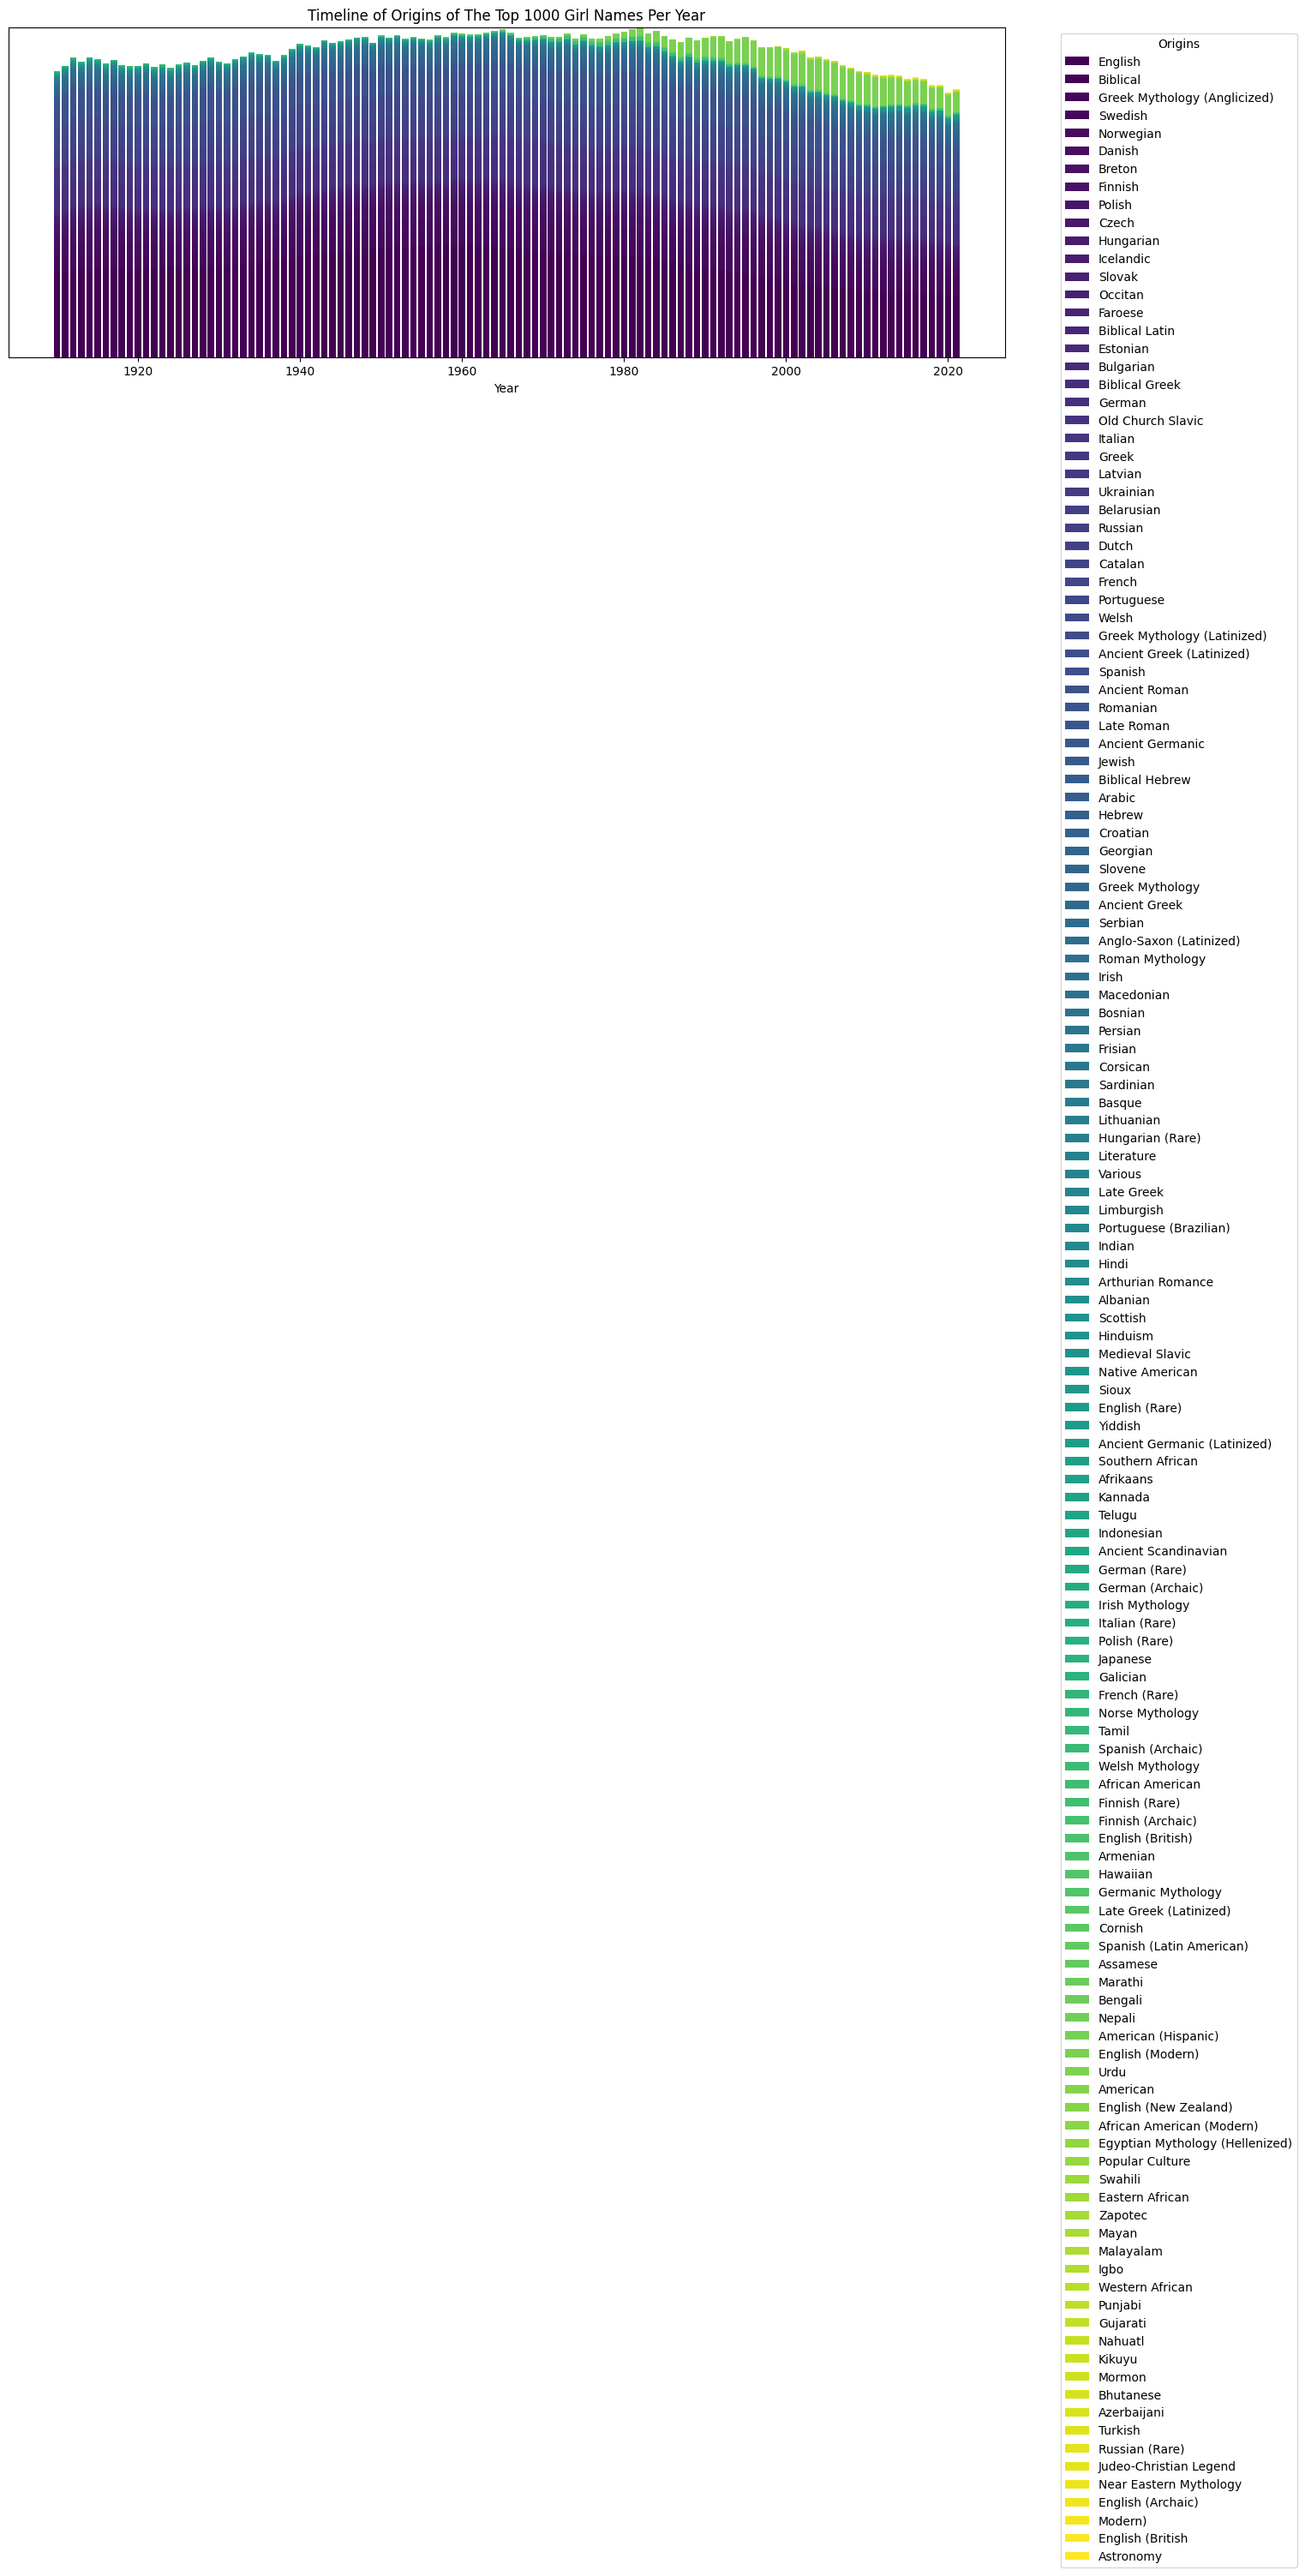

In [ ]:
plot_origins(origin_girl_data, "Top", 1000, "Girl")

In [ ]:
origin_boy_query = """
SELECT
  gy.year,
  gy.name AS name,
  o.origins
FROM names_ranked.boys_yearly AS gy
JOIN names_ranked.origin AS o
ON gy.name = o.name AND (o.gender = 'M' OR o.gender = 'M&F')
ORDER BY gy.year;
 """

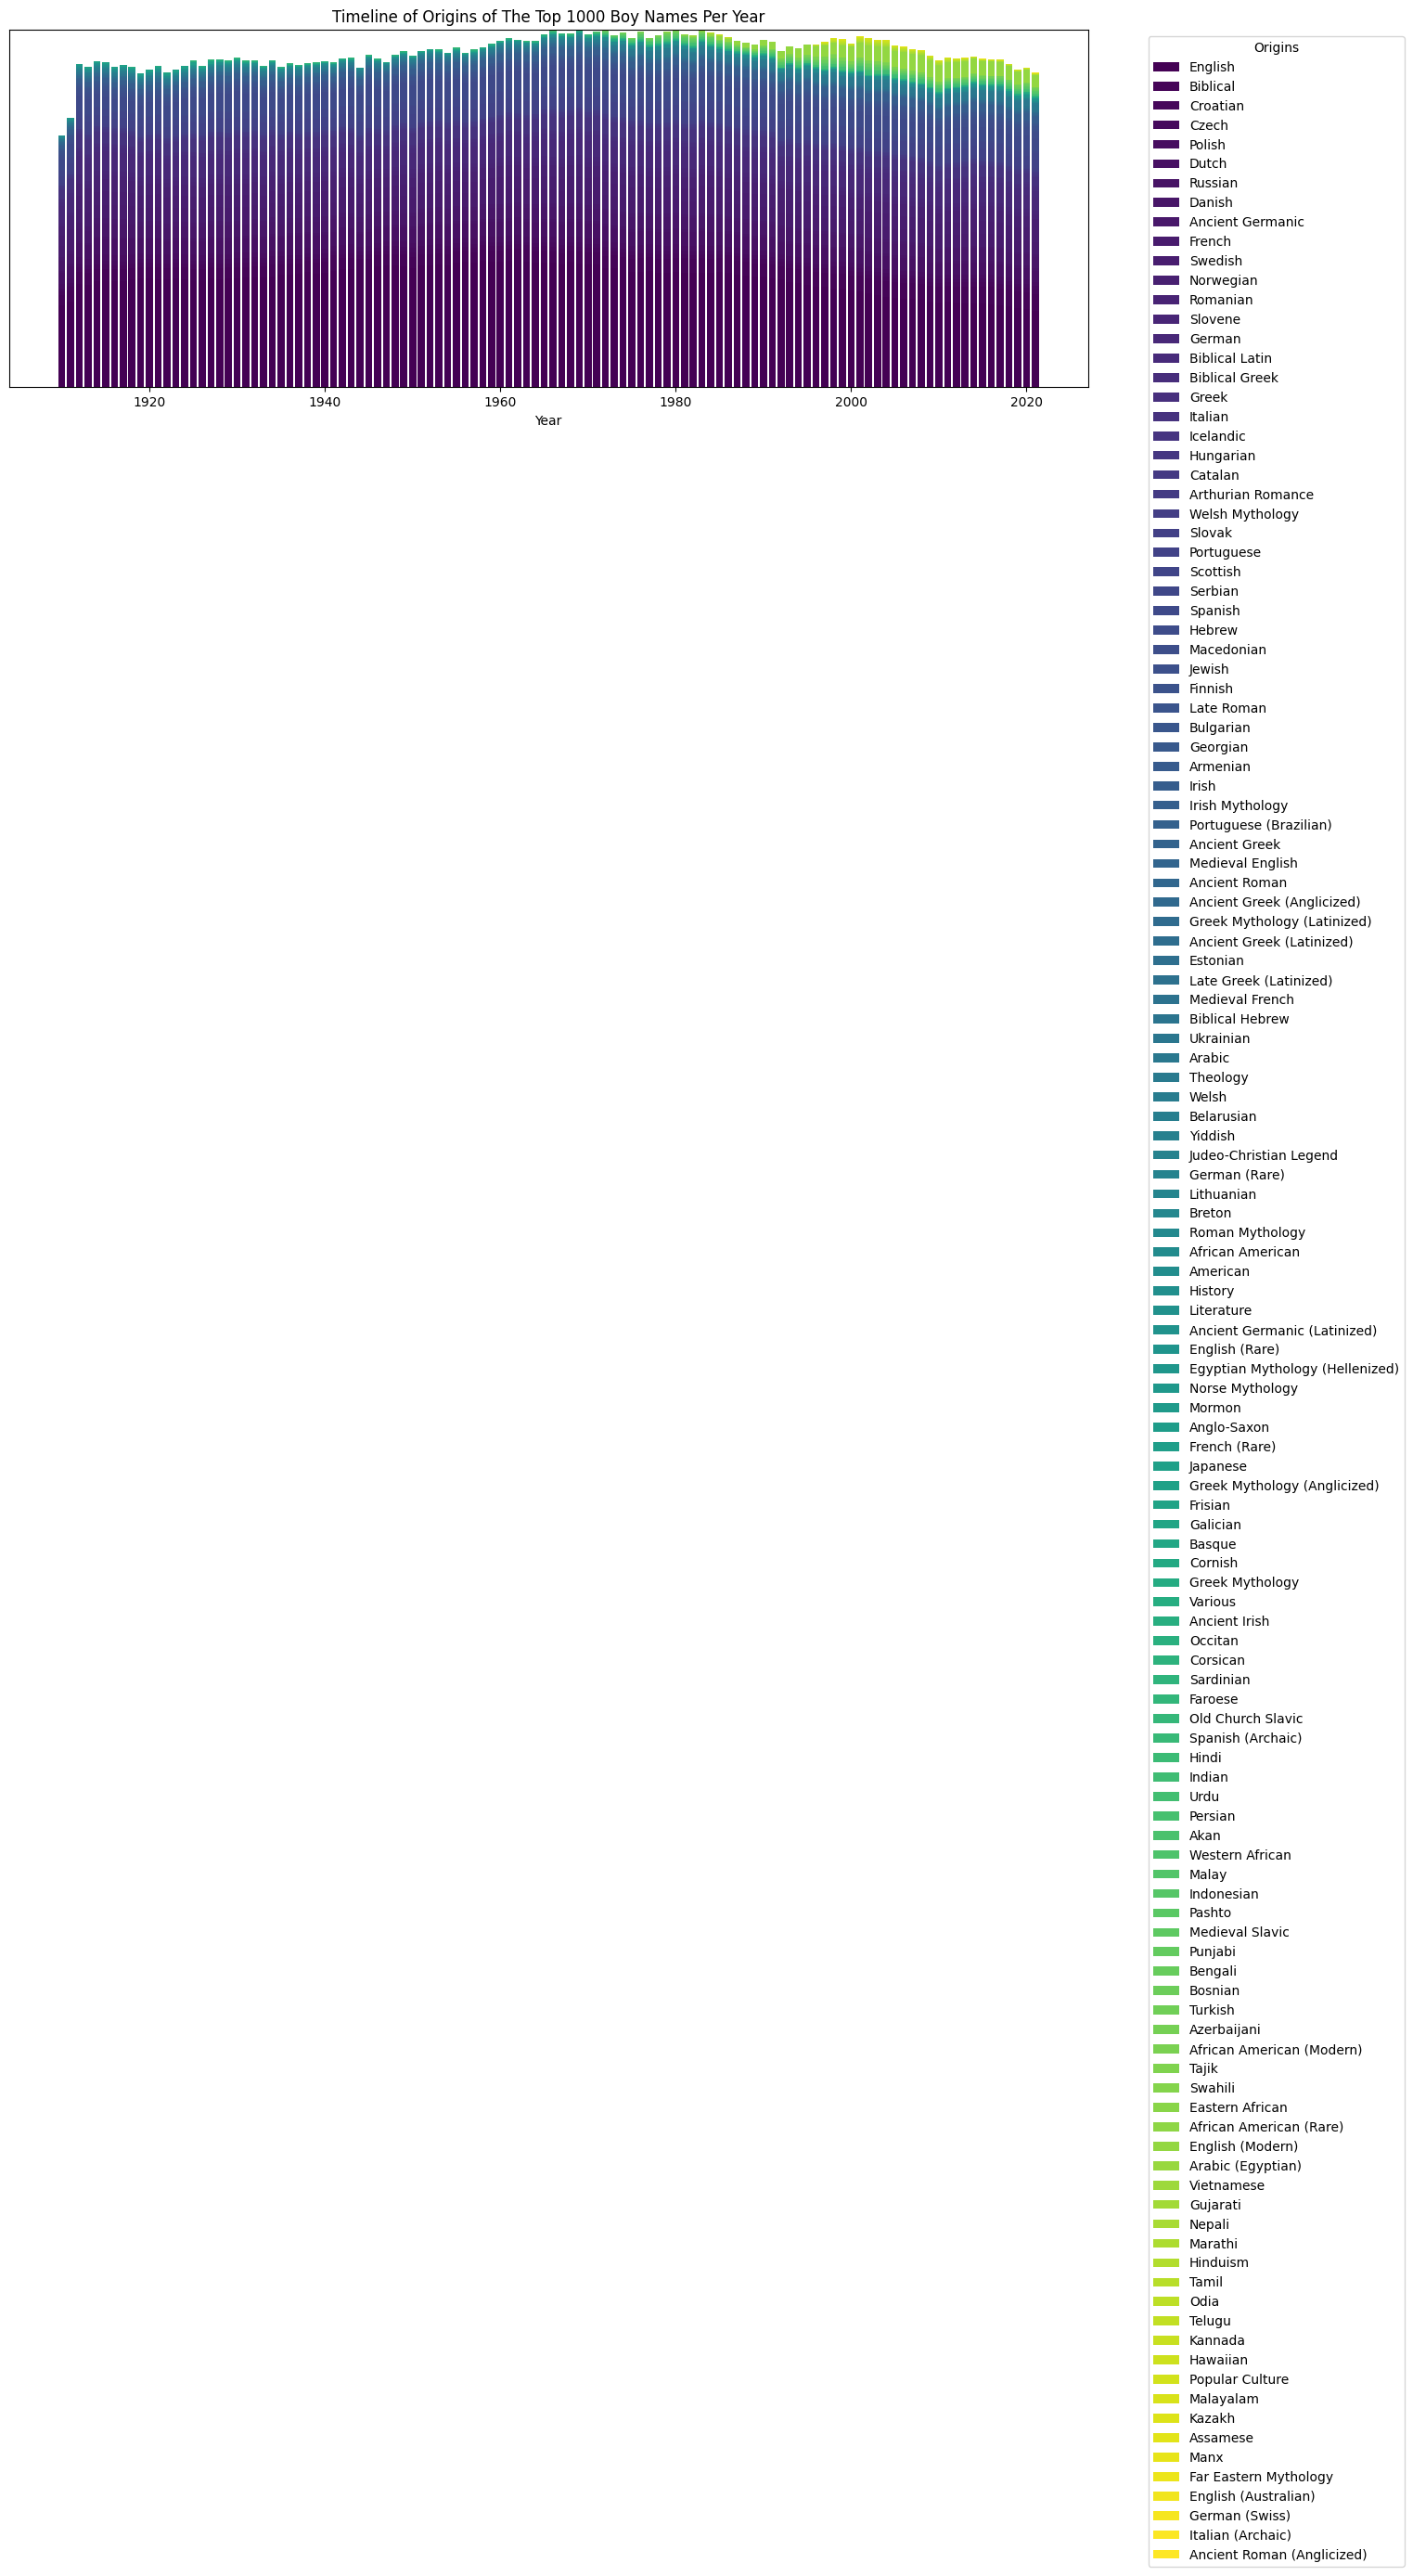

In [ ]:
origin_boy_data = client.query(origin_boy_query).result().to_dataframe()
plot_origins(origin_boy_data, "Top", 1000, "Boy")

Right away, there seems to be a remarkable icrease in origin diversity over the years.

In [ ]:
origin_girl_query_100 = """
SELECT
  gy.year,
  gy.name AS name,
  o.origins
FROM
  names_ranked.girls_yearly AS gy
JOIN
  names_ranked.origin AS o
ON
  gy.name = o.name AND (o.gender = 'F' OR o.gender = 'M&F')
WHERE
  gy.yearly_rank <= 100
ORDER BY
  gy.year;
 """

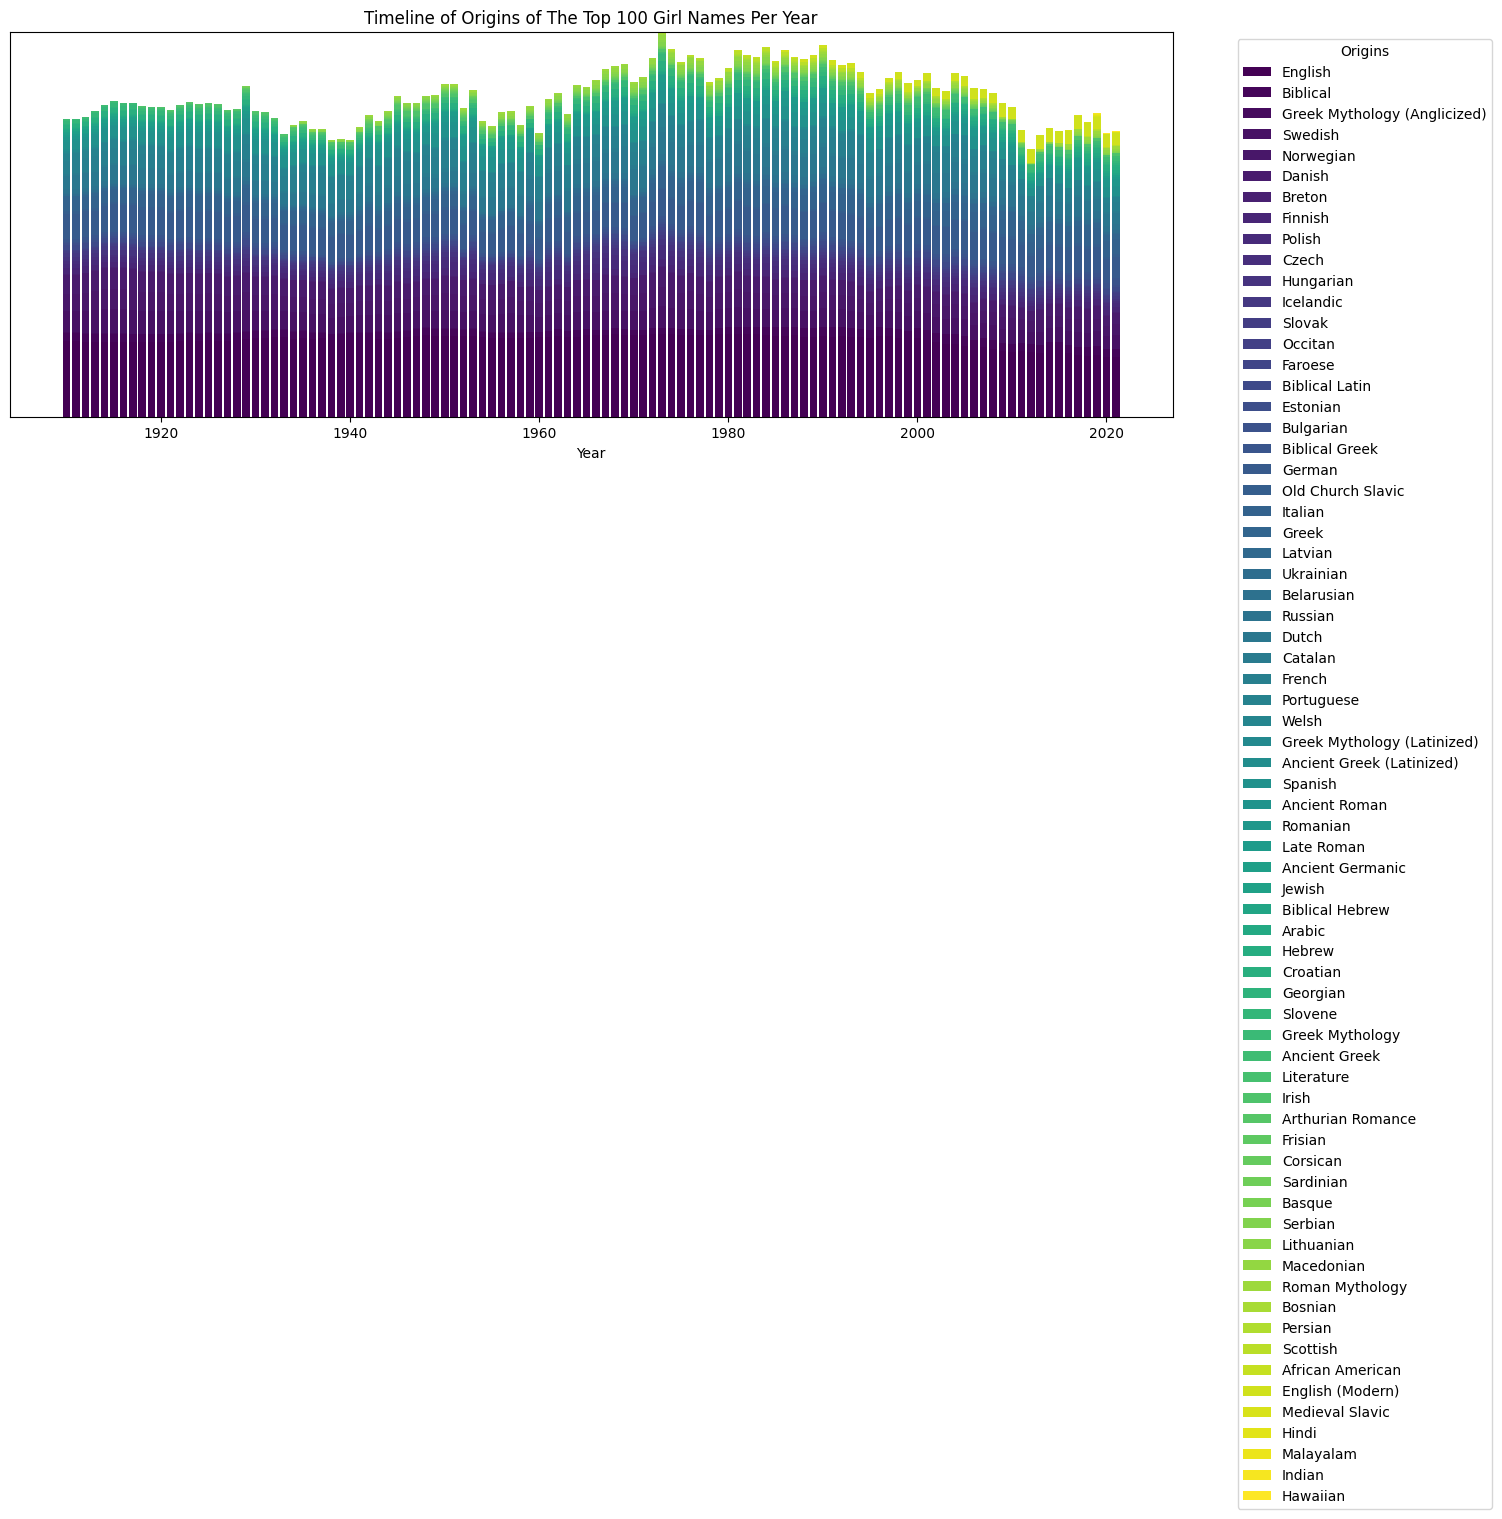

In [ ]:
origin_girl_data_100 = client.query(origin_girl_query_100).result().to_dataframe()
plot_origins(origin_girl_data_100,"Top", 100, "Girl")

In [ ]:
origin_boy_query_100 = """
SELECT
  gy.year,
  gy.name AS name,
  o.origins
FROM
  names_ranked.boys_yearly AS gy
JOIN
  names_ranked.origin AS o
ON
  gy.name = o.name AND (o.gender = 'M' OR o.gender = 'M&F')
WHERE
  gy.yearly_rank <= 100
ORDER BY
  gy.year;
 """

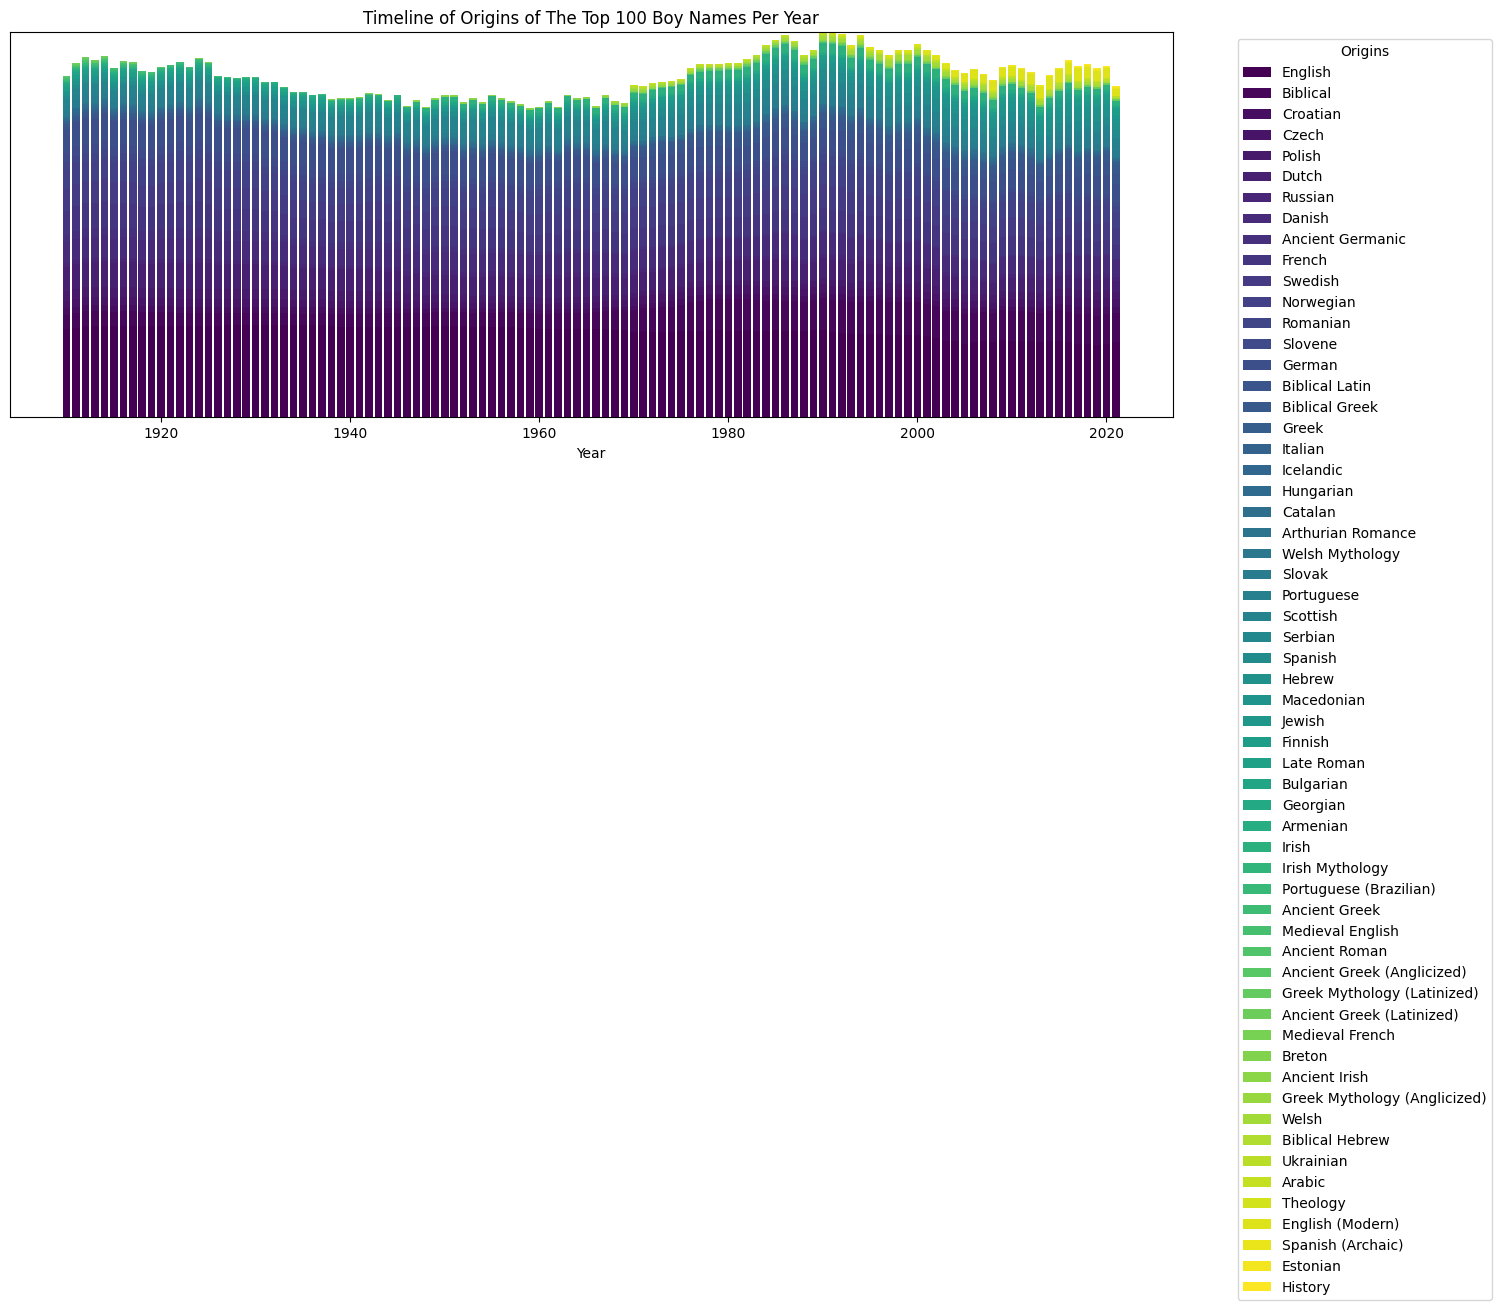

In [ ]:
origin_boy_data_100 = client.query(origin_boy_query_100).result().to_dataframe()
plot_origins(origin_boy_data_100,"Top", 100, "Boy")

We can also see that there is less diversity within the higher ranks of names. It would be interesting to look at demographical trends over the years and tie that into diversity. Unfortunately, there is not enough data in the ACS to span a meaningful timeline. Again, a lot of these temporal explorations were out of pure curiosity, and it's important to understand the different parts of your data before settling on what you can work with.

Now, let's look at the demographical data from the ACS. Here, we've singled out a few indicators that may be valuable for our later analysis. We are also aggregating all of the years together and singling out only the demographical data we want into a table in order to use the information more readily.

In [ ]:
%%bigquery --project $project_id
CREATE SCHEMA IF NOT EXISTS socioecon;
CREATE OR REPLACE TABLE socioecon.ind AS
    WITH combined_data AS(
    SELECT geo_id, total_pop, white_pop, black_pop, asian_pop, hispanic_pop, amerindian_pop, other_race_pop,
      two_or_more_races_pop, median_income, households_public_asst_or_food_stamps,
      bachelors_degree_or_higher_25_64, high_school_including_ged, less_than_high_school_graduate
    FROM `bigquery-public-data.census_bureau_acs.state_2007_1yr`
    UNION ALL
    SELECT geo_id, total_pop, white_pop, black_pop, asian_pop, hispanic_pop, amerindian_pop, other_race_pop,
      two_or_more_races_pop, median_income, households_public_asst_or_food_stamps,
      bachelors_degree_or_higher_25_64, high_school_including_ged, less_than_high_school_graduate
    FROM `bigquery-public-data.census_bureau_acs.state_2008_1yr`
    UNION ALL
    SELECT geo_id, total_pop, white_pop, black_pop, asian_pop, hispanic_pop, amerindian_pop, other_race_pop,
      two_or_more_races_pop, median_income, households_public_asst_or_food_stamps,
      bachelors_degree_or_higher_25_64, high_school_including_ged, less_than_high_school_graduate
    FROM `bigquery-public-data.census_bureau_acs.state_2009_1yr`
    UNION ALL
    SELECT geo_id, total_pop, white_pop, black_pop, asian_pop, hispanic_pop, amerindian_pop, other_race_pop,
      two_or_more_races_pop, median_income, households_public_asst_or_food_stamps,
      bachelors_degree_or_higher_25_64, high_school_including_ged, less_than_high_school_graduate
    FROM `bigquery-public-data.census_bureau_acs.state_2010_1yr`
    UNION ALL
    SELECT geo_id, total_pop, white_pop, black_pop, asian_pop, hispanic_pop, amerindian_pop, other_race_pop,
      two_or_more_races_pop, median_income, households_public_asst_or_food_stamps,
      bachelors_degree_or_higher_25_64, high_school_including_ged, less_than_high_school_graduate
    FROM `bigquery-public-data.census_bureau_acs.state_2011_1yr`
    UNION ALL
    SELECT geo_id, total_pop, white_pop, black_pop, asian_pop, hispanic_pop, amerindian_pop, other_race_pop,
      two_or_more_races_pop, median_income, households_public_asst_or_food_stamps,
      bachelors_degree_or_higher_25_64, high_school_including_ged, less_than_high_school_graduate
    FROM `bigquery-public-data.census_bureau_acs.state_2012_1yr`
    UNION ALL
    SELECT geo_id, total_pop, white_pop, black_pop, asian_pop, hispanic_pop, amerindian_pop, other_race_pop,
      two_or_more_races_pop, median_income, households_public_asst_or_food_stamps,
      bachelors_degree_or_higher_25_64, high_school_including_ged, less_than_high_school_graduate
    FROM `bigquery-public-data.census_bureau_acs.state_2013_1yr`
    UNION ALL
    SELECT geo_id, total_pop, white_pop, black_pop, asian_pop, hispanic_pop, amerindian_pop, other_race_pop,
      two_or_more_races_pop, median_income, households_public_asst_or_food_stamps,
      bachelors_degree_or_higher_25_64, high_school_including_ged, less_than_high_school_graduate
    FROM `bigquery-public-data.census_bureau_acs.state_2014_1yr`
    UNION ALL
    SELECT geo_id, total_pop, white_pop, black_pop, asian_pop, hispanic_pop, amerindian_pop, other_race_pop,
      two_or_more_races_pop, median_income, households_public_asst_or_food_stamps,
      bachelors_degree_or_higher_25_64, high_school_including_ged, less_than_high_school_graduate
    FROM `bigquery-public-data.census_bureau_acs.state_2015_1yr`
    UNION ALL
    SELECT geo_id, total_pop, white_pop, black_pop, asian_pop, hispanic_pop, amerindian_pop, other_race_pop,
      two_or_more_races_pop, median_income, households_public_asst_or_food_stamps,
      bachelors_degree_or_higher_25_64, high_school_including_ged, less_than_high_school_graduate
    FROM `bigquery-public-data.census_bureau_acs.state_2016_1yr`
    UNION ALL
    SELECT geo_id, total_pop, white_pop, black_pop, asian_pop, hispanic_pop, amerindian_pop, other_race_pop,
      two_or_more_races_pop, median_income, households_public_asst_or_food_stamps,
      bachelors_degree_or_higher_25_64, high_school_including_ged, less_than_high_school_graduate
    FROM `bigquery-public-data.census_bureau_acs.state_2017_1yr`
    UNION ALL
    SELECT geo_id, total_pop, white_pop, black_pop, asian_pop, hispanic_pop, amerindian_pop, other_race_pop,
      two_or_more_races_pop, median_income, households_public_asst_or_food_stamps,
      bachelors_degree_or_higher_25_64, high_school_including_ged, less_than_high_school_graduate
    FROM `bigquery-public-data.census_bureau_acs.state_2018_1yr`
    UNION ALL
    SELECT geo_id, total_pop, white_pop, black_pop, asian_pop, hispanic_pop, amerindian_pop, other_race_pop,
      two_or_more_races_pop, median_income, households_public_asst_or_food_stamps,
      bachelors_degree_or_higher_25_64, high_school_including_ged, less_than_high_school_graduate
    FROM `bigquery-public-data.census_bureau_acs.state_2019_1yr`
    UNION ALL
    SELECT geo_id, total_pop, white_pop, black_pop, asian_pop, hispanic_pop, amerindian_pop, other_race_pop,
      two_or_more_races_pop, median_income, households_public_asst_or_food_stamps,
      bachelors_degree_or_higher_25_64, high_school_including_ged, less_than_high_school_graduate
    FROM bigquery-public-data.census_bureau_acs.state_2021_1yr
)
SELECT
    LPAD(geo_id, 2, '0') AS fips,
    AVG(white_pop) / AVG(total_pop) AS white_pop_percentage,
    AVG(black_pop) / AVG(total_pop) AS black_pop_percentage,
    AVG(asian_pop) / AVG(total_pop) AS asian_pop_percentage,
    AVG(hispanic_pop) / AVG(total_pop) AS hispanic_pop_percentage,
    AVG(amerindian_pop) / AVG(total_pop) AS amerindian_pop_percentage,
    AVG(other_race_pop) / AVG(total_pop) AS other_race_pop_percentage,
    AVG(two_or_more_races_pop) / AVG(total_pop) AS two_or_more_races_pop_percentage,
    AVG(median_income) AS median_income,
    AVG(households_public_asst_or_food_stamps) / AVG(total_pop) AS households_public_asst_or_food_stamps_percentage,
    AVG(bachelors_degree_or_higher_25_64) / AVG(total_pop) AS bachelors_degree_or_higher_percentage,
    AVG(less_than_high_school_graduate) / AVG(total_pop) AS no_high_school_diploma
FROM combined_data
GROUP BY fips

Query is running:   0%|          |

""


Unfortunately, there isn't any away to connect the geo_id to the state_code in the dataset. Here is a github file we found that maps the state fips to the state code.

https://raw.githubusercontent.com/kjhealy/fips-codes/master/state_fips_master.csv

In [ ]:
url = 'https://raw.githubusercontent.com/kjhealy/fips-codes/master/state_fips_master.csv'
state_fips = pd.read_csv(url)
state_fips.head()

Put your project id below:

In [ ]:
dataset_id = f"{Project_ID_Here}.states"
dataset = bigquery.Dataset(dataset_id)
dataset.location = "US"
client.create_dataset(dataset, exists_ok=True)
destination = f"{Project_ID_Here}.states.state_codes"

In [ ]:

state_fips.to_gbq(destination, project_id=project_id, if_exists='fail')

100%|██████████| 1/1 [00:00<00:00, 679.46it/s]

Table Codes created in dataset states.


In [ ]:
%%bigquery --project $project_id
SELECT * from states.state_codes
LIMIT 10

Query is running:   0%|          |

Downloading:   0%|          |

,state_name,state_abbr,long_name,fips,sumlev,region,division,state,region_name,division_name
0,Connecticut,CT,Connecticut CT,9,40,1,1,9,Northeast,New England
1,Maine,ME,Maine ME,23,40,1,1,23,Northeast,New England
2,Massachusetts,MA,Massachusetts MA,25,40,1,1,25,Northeast,New England
3,New Hampshire,NH,New Hampshire NH,33,40,1,1,33,Northeast,New England
4,Rhode Island,RI,Rhode Island RI,44,40,1,1,44,Northeast,New England
5,Vermont,VT,Vermont VT,50,40,1,1,50,Northeast,New England
6,New Jersey,NJ,New Jersey NJ,34,40,1,2,34,Northeast,Middle Atlantic
7,New York,NY,New York NY,36,40,1,2,36,Northeast,Middle Atlantic
8,Pennsylvania,PA,Pennsylvania PA,42,40,1,2,42,Northeast,Middle Atlantic
9,Illinois,IL,Illinois IL,17,40,2,3,17,Midwest,East North Central


Let's clean this up a little bit to make it easier for us to use.

In [ ]:
%%bigquery --project $project_id
ALTER TABLE socioecon.ind
ADD COLUMN fips_int INT64;

--Populate the new column with INTEGER FIPS
UPDATE socioecon.ind
SET fips_int = CAST(fips AS INT64)
WHERE TRUE;

--Remove the original fips column
ALTER TABLE socioecon.ind
DROP COLUMN fips;

-- Rename fips_int to fips
ALTER TABLE socioecon.ind
RENAME COLUMN fips_int TO fips;

Query is running:   0%|          |

""


Now, let's create our own table, matching the fips code to the state code in the table we created.

In [ ]:
%%bigquery --project $project_id
CREATE OR REPLACE TABLE socioecon.states AS
  SELECT sc.state_abbr as state, si.*
  FROM states.state_codes as sc
  INNER JOIN socioecon.ind as si
  ON sc.fips = si.fips



Query is running:   0%|          |

""


In [ ]:
%%bigquery --project $project_id
SELECT * from socioecon.states

Query is running:   0%|          |

Downloading:   0%|          |

,state,white_pop_percentage,black_pop_percentage,asian_pop_percentage,hispanic_pop_percentage,amerindian_pop_percentage,other_race_pop_percentage,two_or_more_races_pop_percentage,median_income,households_public_asst_or_food_stamps_percentage,bachelors_degree_or_higher_percentage,no_high_school_diploma,fips
0,MN,0.816050,0.055269,0.043578,0.049629,0.009554,0.001577,0.024035,63022.214286,0.033945,0.192932,0.049981,27
1,MT,0.867138,0.004379,0.006933,0.033593,0.061429,0.000829,0.025038,48815.928571,0.041203,0.160640,0.050383,30
2,AZ,0.559771,0.039786,0.028913,0.307584,0.039390,0.001655,0.021211,52963.000000,0.044354,0.141424,0.091645,4
3,NM,0.388863,0.018511,0.013487,0.474415,0.086067,0.001965,0.016234,45375.285714,0.059050,0.131731,0.102432,35
4,IN,0.803778,0.089878,0.018710,0.063681,0.001773,0.001722,0.020184,50639.785714,0.043197,0.136532,0.079378,18
5,GA,0.543760,0.305698,0.035628,0.090804,0.001753,0.002845,0.019014,52333.142857,0.048512,0.164123,0.092671,13
6,MI,0.757642,0.137171,0.027580,0.047398,0.004678,0.001523,0.023780,51173.785714,0.059240,0.150959,0.069609,26
7,AL,0.663604,0.263881,0.011974,0.038469,0.004334,0.001298,0.016128,44821.714286,0.055614,0.130095,0.104757,1
8,CT,0.690351,0.096003,0.041099,0.146817,0.001436,0.003793,0.020272,70978.714286,0.044303,0.212673,0.070332,9
9,MO,0.801624,0.113334,0.017367,0.038032,0.003479,0.001633,0.023573,49762.071429,0.049326,0.153394,0.076632,29


## Data Exploration Continued: Indicators

Now that we have all the data cleaned and ready to use, let's create some maps! Here, we are mapping our indicators across regions to see how the US differs by region and indicator.

In [ ]:
population_query = """
SELECT * from socioecon.states
"""

population_data = client.query(population_query).result().to_dataframe()

def plot_breakdown(indicator, title, color):
  fig = px.choropleth(
    population_data,
    locations='state',
    color= indicator,
    hover_name='state',
    locationmode='USA-states',
    scope="usa",
    color_continuous_scale= color,
    labels={indicator},
    template='plotly',
  )

  fig.update_layout(
    title_text= title,
    geo=dict(
        showframe=False,
        showcoastlines=False,
    )
  )
  fig.show()

In [ ]:
plot_breakdown('white_pop_percentage', 'US by White Population', px.colors.sequential.ice)
plot_breakdown('median_income', 'US by Median Income', px.colors.sequential.deep)
plot_breakdown('households_public_asst_or_food_stamps_percentage',
               'US by Households Requiring Public Assistance', px.colors.sequential.YlOrRd)
plot_breakdown('median_income', 'US by Population With Bachelors or Higher', px.colors.sequential.deep)
plot_breakdown('no_high_school_diploma', 'US by Population With No High School Degree', px.colors.sequential.Burgyl)

Pretty interesting! It'll be interesting to see how this plays into our name diversity analysis. Let's look at some popular names by indicator value.

In [ ]:
%%bigquery --project $project_id
CREATE OR REPLACE TEMP TABLE RankedNames AS
SELECT state, gender, name, total, rank
FROM (
  SELECT state, gender, name, SUM(number) AS total,
    RANK() OVER(
      PARTITION BY state, gender
      ORDER BY SUM(number) DESC
      ) AS rank
  FROM bigquery-public-data.usa_names.usa_1910_current
  WHERE year BETWEEN 2007 AND 2021
  GROUP BY state, gender, name
)
WHERE rank <= 1000;

CREATE OR REPLACE TABLE socioecon.name_ind AS
SELECT s.*, rn.name, rn.gender, rn.total, rn.rank
FROM socioecon.states AS s
INNER JOIN RankedNames AS rn
ON s.state = rn.state


Query is running:   0%|          |

""


In [ ]:
%%bigquery --project $project_id
WITH TopStates AS (
    SELECT state
    FROM socioecon.name_ind
    GROUP BY state
    ORDER BY AVG(white_pop_percentage) DESC
    LIMIT 5
),
RankedBoys AS (
    SELECT name, SUM(total) as total
    FROM socioecon.name_ind
    WHERE gender = 'M' AND state IN (SELECT state FROM TopStates)
    GROUP BY name
    ORDER BY total DESC
    LIMIT 10
),
RankedGirls AS (
    SELECT name, SUM(total) as total
    FROM socioecon.name_ind
    WHERE gender = 'F' AND state IN (SELECT state FROM TopStates)
    GROUP BY name
    ORDER BY total DESC
    LIMIT 10
),
RankedBoysNumbered AS (
    SELECT name, ROW_NUMBER() OVER (ORDER BY total DESC) as row_num
    FROM RankedBoys
),
RankedGirlsNumbered AS (
    SELECT name, ROW_NUMBER() OVER (ORDER BY total DESC) as row_num
    FROM RankedGirls
)
SELECT
    rb.name AS Boy_Names_High_White_Population_States,
    rg.name AS Girl_Names_High_White_Population_States
FROM
    RankedBoysNumbered rb
FULL OUTER JOIN
    RankedGirlsNumbered rg
ON
    rb.row_num = rg.row_num;




Query is running:   0%|          |

Downloading:   0%|          |

,Boy_Names_High_White_Population_States,Girl_Names_High_White_Population_States
0,Mason,Ava
1,William,Sophia
2,Liam,Emma
3,Owen,Isabella
4,Logan,Madison
5,Jackson,Abigail
6,Noah,Olivia
7,Jacob,Charlotte
8,Benjamin,Addison
9,Wyatt,Ella


In [ ]:
%%bigquery --project $project_id
WITH TopStates AS ( SELECT state FROM socioecon.name_ind GROUP BY state ORDER BY AVG(asian_pop_percentage) DESC LIMIT 5),
RankedBoys AS (SELECT name, SUM(total) as total FROM socioecon.name_ind WHERE gender = 'M' AND state IN (SELECT state FROM TopStates)
    GROUP BY name ORDER BY total DESC LIMIT 10),
RankedGirls AS (SELECT name, SUM(total) as total FROM socioecon.name_ind WHERE gender = 'F' AND state IN (SELECT state FROM TopStates)
    GROUP BY name ORDER BY total DESC LIMIT 10),
RankedBoysNumbered AS (SELECT name, ROW_NUMBER() OVER (ORDER BY total DESC) as row_num FROM RankedBoys),
RankedGirlsNumbered AS (SELECT name, ROW_NUMBER() OVER (ORDER BY total DESC) as row_num FROM RankedGirls)
SELECT
    rb.name AS Boy_Names_High_Asian_Population_States,
    rg.name AS Girl_Names_High_Asian_Population_States
FROM RankedBoysNumbered rb
FULL OUTER JOIN RankedGirlsNumbered rg
ON rb.row_num = rg.row_num;

Query is running:   0%|          |

Downloading:   0%|          |

,Boy_Names_High_Asian_Population_States,Girl_Names_High_Asian_Population_States
0,Daniel,Isabella
1,Michael,Ava
2,Jayden,Madison
3,Ethan,Olivia
4,Noah,Emma
5,Jacob,Sophia
6,Anthony,Abigail
7,Alexander,Emily
8,Liam,Sofia
9,Matthew,Mia


In [ ]:
%%bigquery --project $project_id
WITH TopStates AS ( SELECT state FROM socioecon.name_ind GROUP BY state ORDER BY AVG(hispanic_pop_percentage) DESC LIMIT 5),
RankedBoys AS (SELECT name, SUM(total) as total FROM socioecon.name_ind WHERE gender = 'M' AND state IN (SELECT state FROM TopStates)
    GROUP BY name ORDER BY total DESC LIMIT 10),
RankedGirls AS (SELECT name, SUM(total) as total FROM socioecon.name_ind WHERE gender = 'F' AND state IN (SELECT state FROM TopStates)
    GROUP BY name ORDER BY total DESC LIMIT 10),
RankedBoysNumbered AS (SELECT name, ROW_NUMBER() OVER (ORDER BY total DESC) as row_num FROM RankedBoys),
RankedGirlsNumbered AS (SELECT name, ROW_NUMBER() OVER (ORDER BY total DESC) as row_num FROM RankedGirls)
SELECT
    rb.name AS Boy_Names_High_Hispanic_Population_States,
    rg.name AS Girl_Names_High_Hispanic_Population_States
FROM RankedBoysNumbered rb
FULL OUTER JOIN RankedGirlsNumbered rg
ON rb.row_num = rg.row_num;

Query is running:   0%|          |

Downloading:   0%|          |

,Boy_Names_High_Hispanic_Population_States,Girl_Names_High_Hispanic_Population_States
0,Matthew,Emily
1,Jayden,Abigail
2,Daniel,Isabella
3,Anthony,Ava
4,Michael,Camila
5,Jacob,Emma
6,Ethan,Mia
7,Noah,Sophia
8,Alexander,Olivia
9,David,Sofia


In [ ]:
%%bigquery --project $project_id
WITH TopStates AS ( SELECT state FROM socioecon.name_ind GROUP BY state ORDER BY AVG(median_income) DESC LIMIT 5),
RankedBoys AS (SELECT name, SUM(total) as total FROM socioecon.name_ind WHERE gender = 'M' AND state IN (SELECT state FROM TopStates)
    GROUP BY name ORDER BY total DESC LIMIT 10),
RankedGirls AS (SELECT name, SUM(total) as total FROM socioecon.name_ind WHERE gender = 'F' AND state IN (SELECT state FROM TopStates)
    GROUP BY name ORDER BY total DESC LIMIT 10),
RankedBoysNumbered AS (SELECT name, ROW_NUMBER() OVER (ORDER BY total DESC) as row_num FROM RankedBoys),
RankedGirlsNumbered AS (SELECT name, ROW_NUMBER() OVER (ORDER BY total DESC) as row_num FROM RankedGirls)
SELECT
    rb.name AS Boy_Names_By_Top_Median_Income_States,
    rg.name AS Girl_Names_By_Top_Median_Income_states
FROM RankedBoysNumbered rb
FULL OUTER JOIN RankedGirlsNumbered rg
ON rb.row_num = rg.row_num;

Query is running:   0%|          |

Downloading:   0%|          |

,Boy_Names_By_Top_Median_Income_States,Girl_Names_By_Top_Median_Income_states
0,Michael,Olivia
1,Jacob,Emma
2,Benjamin,Abigail
3,Matthew,Ava
4,Noah,Sophia
5,Daniel,Emily
6,Joseph,Madison
7,William,Mia
8,Liam,Isabella
9,Ryan,Charlotte


In [ ]:
%%bigquery --project $project_id
WITH TopStates AS ( SELECT state FROM socioecon.name_ind GROUP BY state ORDER BY AVG(median_income) ASC LIMIT 5),
RankedBoys AS (SELECT name, SUM(total) as total FROM socioecon.name_ind WHERE gender = 'M' AND state IN (SELECT state FROM TopStates)
    GROUP BY name ORDER BY total DESC LIMIT 10),
RankedGirls AS (SELECT name, SUM(total) as total FROM socioecon.name_ind WHERE gender = 'F' AND state IN (SELECT state FROM TopStates)
    GROUP BY name ORDER BY total DESC LIMIT 10),
RankedBoysNumbered AS (SELECT name, ROW_NUMBER() OVER (ORDER BY total DESC) as row_num FROM RankedBoys),
RankedGirlsNumbered AS (SELECT name, ROW_NUMBER() OVER (ORDER BY total DESC) as row_num FROM RankedGirls)
SELECT
    rb.name AS Boy_Names_By_Bottom_Median_Income_States,
    rg.name AS Girl_Names_By_Bottom_Median_Income_states
FROM RankedBoysNumbered rb
FULL OUTER JOIN RankedGirlsNumbered rg
ON rb.row_num = rg.row_num;

Query is running:   0%|          |

Downloading:   0%|          |

,Boy_Names_By_Bottom_Median_Income_States,Girl_Names_By_Bottom_Median_Income_states
0,James,Ava
1,Jacob,Abigail
2,Noah,Isabella
3,Jackson,Sophia
4,Elijah,Olivia
5,Aiden,Chloe
6,Michael,Elizabeth
7,John,Addison
8,Mason,Madison
9,William,Emma


In [ ]:
%%bigquery --project $project_id
WITH TopStates AS ( SELECT state FROM socioecon.name_ind GROUP BY state ORDER BY AVG(bachelors_degree_or_higher_percentage) ASC LIMIT 5),
RankedBoys AS (SELECT name, SUM(total) as total FROM socioecon.name_ind WHERE gender = 'M' AND state IN (SELECT state FROM TopStates)
    GROUP BY name ORDER BY total DESC LIMIT 10),
RankedGirls AS (SELECT name, SUM(total) as total FROM socioecon.name_ind WHERE gender = 'F' AND state IN (SELECT state FROM TopStates)
    GROUP BY name ORDER BY total DESC LIMIT 10),
RankedBoysNumbered AS (SELECT name, ROW_NUMBER() OVER (ORDER BY total DESC) as row_num FROM RankedBoys),
RankedGirlsNumbered AS (SELECT name, ROW_NUMBER() OVER (ORDER BY total DESC) as row_num FROM RankedGirls)
SELECT
    rb.name AS Boy_Names_By_Top_Educated_States,
    rg.name AS Boy_Names_By_Top_Educated_States
FROM RankedBoysNumbered rb
FULL OUTER JOIN RankedGirlsNumbered rg
ON rb.row_num = rg.row_num;

Query is running:   0%|          |

Downloading:   0%|          |

,Boy_Names_By_Top_Educated_States,Boy_Names_By_Top_Educated_States_1
0,Aiden,Emily
1,James,Madison
2,Jacob,Sophia
3,John,Addison
4,Ethan,Chloe
5,Elijah,Isabella
6,Noah,Ava
7,Michael,Abigail
8,Mason,Olivia
9,William,Emma


In [ ]:
%%bigquery --project $project_id
WITH TopStates AS ( SELECT state FROM socioecon.name_ind GROUP BY state ORDER BY AVG(no_high_school_diploma) ASC LIMIT 5),
RankedBoys AS (SELECT name, SUM(total) as total FROM socioecon.name_ind WHERE gender = 'M' AND state IN (SELECT state FROM TopStates)
    GROUP BY name ORDER BY total DESC LIMIT 10),
RankedGirls AS (SELECT name, SUM(total) as total FROM socioecon.name_ind WHERE gender = 'F' AND state IN (SELECT state FROM TopStates)
    GROUP BY name ORDER BY total DESC LIMIT 10),
RankedBoysNumbered AS (SELECT name, ROW_NUMBER() OVER (ORDER BY total DESC) as row_num FROM RankedBoys),
RankedGirlsNumbered AS (SELECT name, ROW_NUMBER() OVER (ORDER BY total DESC) as row_num FROM RankedGirls)
SELECT
    rb.name AS Boy_Names_By_Least_Educated_States,
    rg.name AS Boy_Names_By_Least_Educated_States
FROM RankedBoysNumbered rb
FULL OUTER JOIN RankedGirlsNumbered rg
ON rb.row_num = rg.row_num;

Query is running:   0%|          |

Downloading:   0%|          |

,Boy_Names_By_Least_Educated_States,Boy_Names_By_Least_Educated_States_1
0,James,Evelyn
1,Jack,Isabella
2,Mason,Ava
3,William,Olivia
4,Liam,Emma
5,Benjamin,Charlotte
6,Owen,Elizabeth
7,Henry,Sophia
8,Ethan,Amelia
9,Oliver,Abigail


Though these were cool to create, they don't offer much insight on how these factors affect naming trends. How about we delve deeper into that using machine learning! Before we do, let's look at all of the unigue origins there are per state.

In [ ]:
%%bigquery --project $project_id

WITH RankedNames AS (
    SELECT state, name, SUM(number) as total_number
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE year BETWEEN 2007 AND 2021
    GROUP BY state, name
    QUALIFY RANK() OVER (PARTITION BY state ORDER BY SUM(number) DESC) <= 1000
),
JoinedOrigins AS (
    SELECT rn.state, nr.origins
    FROM RankedNames rn
    JOIN `names_ranked.origin` nr ON rn.name = nr.name
)

SELECT state, origins, COUNT(origins) as origin_count
FROM JoinedOrigins
GROUP BY state, origins
ORDER BY state, origin_count DESC




Query is running:   0%|          |

Downloading:   0%|          |

,state,origins,origin_count
0,AK,English,610
1,AK,English (Modern),156
2,AK,German,133
3,AK,Swedish,109
4,AK,Dutch,99
...,...,...,...
4994,WY,Spanish (Archaic),1
4995,WY,Judeo-Christian Legend,1
4996,WY,Bosnian,1
4997,WY,Irish Mythology,1


## ML Model

Let's first create a dataset to store all of our info for the model.

In [ ]:
# Run this cell to create a dataset to store your model, or create in the UI
model_dataset_name = 'ml'

dataset = bigquery.Dataset(client.dataset(model_dataset_name))
dataset.location = 'US'
client.create_dataset(dataset)

Dataset(DatasetReference('bn-project-1-401808', 'ml'))

Now let's talk about diversity. From the beginning, we knew we wanted to look at etymological diversity, but it seemed very complicated to turn what could be an entire book into a binary or a series of buckets. In order to get all this data and what we want to predict to fit the scope of the ML model, we first need to take a page or two out of biology.

The Simpson's Diversity Index is a measure of how diverse a given habitat is. It takes into account the number of species present, as well as the relative abundance of each species. As species richness and evenness increase, so  does biodiversity. The index ranges from 0 to 1. The closer to 1 the index, the higher the diversity. Though not a metric intended for names, we really wanted to look at the richness and evenness of names across the US as opposed to just the variety. For the purposes of this project, let's say that all of the distinct origins of names are "species" and the aggregate count of all the origins is the "population". The formula is as follows:

*D = 1 - (∑(n(n-10))/(N(N-1))*

Where

**D** = the diversity index (the higher, the more diverse)

**n** = the total count within a distinct species (origin)

**N** = the total number of individuals

Where this gets murky is that, for our setup, a given name can have many origins, and therefore belong to many "species". This may affect the efficacy of the index, but from past exploration, we see that origins that are more common like english or german, also tend to be more plentiful within the population, meaning the more popular names tend to have those distinct origins. Therefore, the index is useful in that it takes into account the weight of each individual origin.


Now, let's first create a table to calculate n and N. The total number of indidivual origins within a state is our n. The total number of counts of all the origins is our N.

In [ ]:
%%bigquery --project $project_id
CREATE OR REPLACE TABLE ml.state AS
WITH RankedNames AS (
    SELECT state, name, SUM(number) as total_number
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE year BETWEEN 2007 AND 2021
    GROUP BY state, name
    QUALIFY RANK() OVER (PARTITION BY state ORDER BY SUM(number) DESC) <= 1000
),
JoinedOrigins AS (
    SELECT rn.state, nr.origins
    FROM RankedNames rn
    JOIN `names_ranked.origin` nr ON rn.name = nr.name
)

SELECT state, origins, COUNT(origins) as origin_count
FROM JoinedOrigins
GROUP BY state, origins
ORDER BY state, origin_count DESC;

Query is running:   0%|          |

""


Now, let's calculate the Simpson's Index based on the formula.

In [ ]:
%%bigquery --project $project_id
CREATE OR REPLACE TABLE ml.simpsons AS
WITH OriginCounts AS (
  SELECT state, origins, origin_count,
         SUM(origin_count) OVER (PARTITION BY state) as total_origins
  FROM `ml.state`
),
DiversityCalc AS (
  SELECT state,
         SUM(origin_count * (origin_count - 1)) as sum_n_nminus1,
         total_origins * (total_origins - 1) as N_Nminus1
  FROM OriginCounts
  GROUP BY state, total_origins
)

SELECT state,
       1 - (sum_n_nminus1 / NULLIF(N_Nminus1, 0)) as simpsons_index
FROM DiversityCalc
ORDER BY simpsons_index

Query is running:   0%|          |

""


Great! Now that we have the index, let's use it to look at some indicators before we continue to the model.

In [ ]:
%%bigquery --project $project_id
WITH OriginCounts AS (
  SELECT state, origins, origin_count,
         SUM(origin_count) OVER (PARTITION BY state) as total_origins
  FROM `ml.state`
),
DiversityCalc AS (
  SELECT state,
         SUM(origin_count * (origin_count - 1)) as sum_n_nminus1,
         total_origins * (total_origins - 1) as N_Nminus1
  FROM OriginCounts
  GROUP BY state, total_origins
)

SELECT state,
       1 - (sum_n_nminus1 / NULLIF(N_Nminus1, 0)) as simpsons_index
FROM DiversityCalc
ORDER BY simpsons_index

Query is running:   0%|          |

Downloading:   0%|          |

,state,simpsons_index
0,MS,0.896615
1,WV,0.896684
2,LA,0.902982
3,MT,0.903342
4,KY,0.905369
5,AL,0.905712
6,MO,0.906012
7,ND,0.907950
8,SD,0.908667
9,AR,0.908917


Now we have a rough sense of the spread of our index

In [ ]:
%%bigquery --project $project_id
SELECT
  d.state,
  d.simpsons_index,
  s.median_income,
  s.no_high_school_diploma,
  1 - s.white_pop_percentage as non_white_percentage,
  s.households_public_asst_or_food_stamps_percentage,
  CASE WHEN d.simpsons_index > 0.915312 THEN 1 ELSE 0 END as simpsons_index_binary
FROM
  ml.simpsons d
JOIN
  socioecon.name_ind s ON d.state = s.state;

Query is running:   0%|          |

Downloading:   0%|          |

,state,simpsons_index,median_income,no_high_school_diploma,non_white_percentage,households_public_asst_or_food_stamps_percentage,simpsons_index_binary
0,AK,0.913439,71022.071429,0.049707,0.377549,0.044343,0
1,AK,0.913439,71022.071429,0.049707,0.377549,0.044343,0
2,AK,0.913439,71022.071429,0.049707,0.377549,0.044343,0
3,AK,0.913439,71022.071429,0.049707,0.377549,0.044343,0
4,AK,0.913439,71022.071429,0.049707,0.377549,0.044343,0
...,...,...,...,...,...,...,...
90110,WY,0.913641,57890.357143,0.048969,0.152870,0.024840,0
90111,WY,0.913641,57890.357143,0.048969,0.152870,0.024840,0
90112,WY,0.913641,57890.357143,0.048969,0.152870,0.024840,0
90113,WY,0.913641,57890.357143,0.048969,0.152870,0.024840,0


Now let's look at how our index looks across a variety of indicators. Grouping by the top 5 states for each indicator, let's see how the index changes.

In [ ]:
%%bigquery --project $project_id
WITH TopStates AS (
  SELECT state
  FROM socioecon.name_ind
  GROUP BY state
  ORDER BY AVG(median_income) DESC
  LIMIT 5)
SELECT AVG(s.simpsons_index) as index_for_high_median_income_states
FROM ml.simpsons s
JOIN TopStates d
ON d.state = s.state
ORDER BY index_for_high_median_income_states


Query is running:   0%|          |

Downloading:   0%|          |

,index_for_high_median_income_states
0,0.924663


In [ ]:
%%bigquery --project $project_id
WITH TopStates AS (
  SELECT state
  FROM socioecon.name_ind
  GROUP BY state
  ORDER BY AVG(median_income) ASC
  LIMIT 5)
SELECT AVG(s.simpsons_index) as index_for_low_median_income_states
FROM ml.simpsons s
JOIN TopStates d
ON d.state = s.state
ORDER BY index_for_low_median_income_states

Query is running:   0%|          |

Downloading:   0%|          |

,index_for_low_median_income_states
0,0.902659


In [ ]:
%%bigquery --project $project_id
WITH TopStates AS (
  SELECT state
  FROM socioecon.name_ind
  GROUP BY state
  ORDER BY AVG(households_public_asst_or_food_stamps_percentage) DESC
  LIMIT 5)
SELECT AVG(s.simpsons_index) as index_high_welfare_states
FROM ml.simpsons s
JOIN TopStates d
ON d.state = s.state
ORDER BY index_high_welfare_states

Query is running:   0%|          |

Downloading:   0%|          |

,index_high_welfare_states
0,0.906751


In [ ]:
%%bigquery --project $project_id
WITH TopStates AS (
  SELECT state
  FROM socioecon.name_ind
  GROUP BY state
  ORDER BY AVG(households_public_asst_or_food_stamps_percentage) ASC
  LIMIT 5)
SELECT AVG(s.simpsons_index) as index_low_welfare_states
FROM ml.simpsons s
JOIN TopStates d
ON d.state = s.state
ORDER BY index_low_welfare_states

Query is running:   0%|          |

Downloading:   0%|          |

,index_low_welfare_states
0,0.92163


In [ ]:
%%bigquery --project $project_id
WITH TopStates AS (
  SELECT state
  FROM socioecon.name_ind
  GROUP BY state
  ORDER BY AVG(no_high_school_diploma) ASC
  LIMIT 5)
SELECT AVG(s.simpsons_index) as index_for_high_educated_states
FROM ml.simpsons s
JOIN TopStates d
ON d.state = s.state
ORDER BY index_for_high_educated_states

Query is running:   0%|          |

Downloading:   0%|          |

,index_for_high_educated_states
0,0.912608


In [ ]:
%%bigquery --project $project_id
WITH TopStates AS (
  SELECT state
  FROM socioecon.name_ind
  GROUP BY state
  ORDER BY AVG(no_high_school_diploma) DESC
  LIMIT 5)
SELECT AVG(s.simpsons_index) as index_for_low_educated_states
FROM ml.simpsons s
JOIN TopStates d
ON d.state = s.state
ORDER BY index_for_low_educated_states

Query is running:   0%|          |

Downloading:   0%|          |

,index_for_low_educated_states
0,0.912732


In [ ]:
%%bigquery --project $project_id
WITH TopStates AS (
  SELECT state
  FROM socioecon.name_ind
  GROUP BY state
  ORDER BY AVG(bachelors_degree_or_higher_percentage) DESC
  LIMIT 5)
SELECT AVG(s.simpsons_index) as index_for_high_college_educated_states
FROM ml.simpsons s
JOIN TopStates d
ON d.state = s.state
ORDER BY index_for_high_college_educated_states

Query is running:   0%|          |

Downloading:   0%|          |

,index_for_high_college_educated_states
0,0.928027


In [ ]:
%%bigquery --project $project_id
WITH TopStates AS (
  SELECT state
  FROM socioecon.name_ind
  GROUP BY state
  ORDER BY AVG(bachelors_degree_or_higher_percentage) ASC
  LIMIT 5)
SELECT AVG(s.simpsons_index) as index_for_low_college_educated_states
FROM ml.simpsons s
JOIN TopStates d
ON d.state = s.state
ORDER BY index_for_low_college_educated_states

Query is running:   0%|          |

Downloading:   0%|          |

,index_for_low_college_educated_states
0,0.906175


In [ ]:
%%bigquery --project $project_id
WITH TopStates AS (
  SELECT state
  FROM socioecon.name_ind
  GROUP BY state
  ORDER BY AVG(white_pop_percentage) DESC
  LIMIT 5)
SELECT AVG(s.simpsons_index) as index_for_high_white_states
FROM ml.simpsons s
JOIN TopStates d
ON d.state = s.state
ORDER BY index_for_high_white_states

Query is running:   0%|          |

Downloading:   0%|          |

,index_for_high_white_states
0,0.908899


In [ ]:
%%bigquery --project $project_id
WITH TopStates AS (
  SELECT state
  FROM socioecon.name_ind
  GROUP BY state
  ORDER BY AVG(white_pop_percentage) ASC
  LIMIT 5)
SELECT AVG(s.simpsons_index) as index_for_low_white_states
FROM ml.simpsons s
JOIN TopStates d
ON d.state = s.state
ORDER BY index_for_low_white_states

Query is running:   0%|          |

Downloading:   0%|          |

,index_for_low_white_states
0,0.927153


In [ ]:
%%bigquery --project $project_id
WITH TopStates AS (
  SELECT state
  FROM socioecon.name_ind
  GROUP BY state
  ORDER BY AVG(black_pop_percentage) DESC
  LIMIT 5)
SELECT AVG(s.simpsons_index) as index_for_high_black_states
FROM ml.simpsons s
JOIN TopStates d
ON d.state = s.state
ORDER BY index_for_high_black_states

Query is running:   0%|          |

Downloading:   0%|          |

,index_for_high_black_states
0,0.909525


In [ ]:
%%bigquery --project $project_id
WITH TopStates AS (
  SELECT state
  FROM socioecon.name_ind
  GROUP BY state
  ORDER BY AVG(asian_pop_percentage) DESC
  LIMIT 5)
SELECT AVG(s.simpsons_index) as index_for_high_asian_states
FROM ml.simpsons s
JOIN TopStates d
ON d.state = s.state
ORDER BY index_for_high_asian_states

Query is running:   0%|          |

Downloading:   0%|          |

,index_for_high_asian_states
0,0.929741


In [ ]:
%%bigquery --project $project_id
WITH TopStates AS (
  SELECT state
  FROM socioecon.name_ind
  GROUP BY state
  ORDER BY AVG(hispanic_pop_percentage) DESC
  LIMIT 5)
SELECT AVG(s.simpsons_index) as index_for_high_hispanic_states
FROM ml.simpsons s
JOIN TopStates d
ON d.state = s.state
ORDER BY index_for_high_hispanic_states

Query is running:   0%|          |

Downloading:   0%|          |

,index_for_high_hispanic_states
0,0.928662


Now we have a good sense of what indicators to use in our regression. It looks like bachelor's degree percentage is a much more potent indicator for our purposes than high school attainment so we will use that as our education determinant. As for the race percentage, since most states are majority white, we will be using the non-white percentage of the population for our race determinant. For income, both median income and welfare seem like potent indicators, so we decided to include both.

In [ ]:
%%bigquery --project $project_id
SELECT
  d.state,
  d.simpsons_index,
  s.median_income,
  s.bachelors_degree_or_higher_percentage,
  1 - s.white_pop_percentage as non_white_percentage,
  s.households_public_asst_or_food_stamps_percentage,
FROM
  ml.simpsons d
JOIN
  socioecon.name_ind s ON d.state = s.state;

Query is running:   0%|          |

Downloading:   0%|          |

,state,simpsons_index,median_income,bachelors_degree_or_higher_percentage,non_white_percentage,households_public_asst_or_food_stamps_percentage
0,MS,0.896615,40313.071429,0.109718,0.427174,0.060358
1,MS,0.896615,40313.071429,0.109718,0.427174,0.060358
2,MS,0.896615,40313.071429,0.109718,0.427174,0.060358
3,MS,0.896615,40313.071429,0.109718,0.427174,0.060358
4,MS,0.896615,40313.071429,0.109718,0.427174,0.060358
...,...,...,...,...,...,...
90110,NJ,0.938456,74133.428571,0.217394,0.428090,0.031392
90111,NJ,0.938456,74133.428571,0.217394,0.428090,0.031392
90112,NJ,0.938456,74133.428571,0.217394,0.428090,0.031392
90113,NJ,0.938456,74133.428571,0.217394,0.428090,0.031392


Now, in order to establish a binary for our model, let's first find the median index so that we can categorize anything over that as "diverse" and anything under as "not diverse".

In [ ]:
%%bigquery --project $project_id
SELECT
  PERCENTILE_CONT(d.simpsons_index, 0.5) OVER() AS median_simpsons_index,
FROM ml.simpsons d

Query is running:   0%|          |

Downloading:   0%|          |

,median_simpsons_index
0,0.915312
1,0.915312
2,0.915312
3,0.915312
4,0.915312
5,0.915312
6,0.915312
7,0.915312
8,0.915312
9,0.915312


Now let's finally create the model.

In [ ]:
%%bigquery --project $project_id
CREATE OR REPLACE MODEL `ml.diversity_model`
OPTIONS(model_type='logistic_reg') AS
  SELECT
    IF(d.simpsons_index >= 0.915312, 1, 0) as label,
    s.median_income,
    s.bachelors_degree_or_higher_percentage,
    1 - s.white_pop_percentage as non_white_percentage,
    s.households_public_asst_or_food_stamps_percentage,
    -- Use MOD function to generate a random number for each row
  FROM ml.simpsons d
  JOIN socioecon.name_ind s
  ON d.state = s.state
  WHERE ABS(MOD(FARM_FINGERPRINT(TO_JSON_STRING(s)), 10)) < 7 -- Use 7 to include roughly 70% of the data in training, keep 8 and 9 unhashed for evaluation


Query is running:   0%|          |

""


Storing the statistics in a table.

In [ ]:
%%bigquery --project $project_id
CREATE SCHEMA IF NOT EXISTS statistics;

-- Creating table
CREATE OR REPLACE TABLE statistics.ml_data (
  label INT64,
  median_income FLOAT64,
  bachelors_degree_or_higher_percentage FLOAT64,
  non_white_percentage FLOAT64,
  households_public_asst_or_food_stamps_percentage FLOAT64
);

INSERT INTO statistics.ml_data (label, median_income, bachelors_degree_or_higher_percentage, non_white_percentage, households_public_asst_or_food_stamps_percentage)
SELECT
    IF(d.simpsons_index >= 0.915312, 1, 0) as label,
    s.median_income,
    s.bachelors_degree_or_higher_percentage,
    1 - s.white_pop_percentage as non_white_percentage,
    s.households_public_asst_or_food_stamps_percentage,
    -- Use MOD function to generate a random number for each row
  FROM ml.simpsons d
  JOIN socioecon.name_ind s
  ON d.state = s.state
  WHERE ABS(MOD(FARM_FINGERPRINT(TO_JSON_STRING(s)), 10)) < 7 -- Use 7 to include roughly 70% of the data in training, keep 8 and 9 unhashed for evaluation


Query is running:   0%|          |

""


Let's look at the information on our model.

In [ ]:
%%bigquery --project $project_id
SELECT *
FROM ML.TRAINING_INFO(MODEL `ml.diversity_model`)

Query is running:   0%|          |

Downloading:   0%|          |

,training_run,iteration,loss,eval_loss,learning_rate,duration_ms
0,0,19,0.000003,0.000003,104857.6,3616
1,0,18,0.000005,0.000005,52428.8,3234
2,0,17,0.000010,0.000010,26214.4,3089
3,0,16,0.000021,0.000021,13107.2,3099
4,0,15,0.000041,0.000042,6553.6,3113
5,0,14,0.000083,0.000083,3276.8,3326
6,0,13,0.000165,0.000166,1638.4,3029
7,0,12,0.000331,0.000333,819.2,3732
8,0,11,0.000663,0.000667,409.6,3741
9,0,10,0.001329,0.001337,204.8,3053


Now that we have our model, let's evaluate it.

In [ ]:
%%bigquery --project $project_id
SELECT
  *
FROM
  ML.EVALUATE(MODEL `ml.diversity_model`, (
    SELECT
    IF(d.simpsons_index >= 0.915312, 1, 0) as label,
    s.median_income,
    s.bachelors_degree_or_higher_percentage,
    1 - s.white_pop_percentage as non_white_percentage,
    s.households_public_asst_or_food_stamps_percentage,
    -- Use MOD function to generate a random number for each row
  FROM ml.simpsons d
  JOIN socioecon.name_ind s
  ON d.state = s.state
  WHERE ABS(MOD(FARM_FINGERPRINT(TO_JSON_STRING(s)), 10)) = 8
  ));


These results are pretty good! The model seems to perform fairly well, but can we make it better?

# Data Cleaning and Engineering Features

Notice earlier that the term 'origin' is quite loose in this dataset. As a consequence English and English (Modern) get their own categories. This may murk up our model, so let's clean all this up.



In [ ]:
%%bigquery --project $project_id%%bigquery --project $project_id
SELECT DISTINCT origins
FROM ml.state

Query is running:   0%|          |

Downloading:   0%|          |

,origins
0,English
1,English (Modern)
2,German
3,Swedish
4,Dutch
...,...
133,Bhutanese
134,Cornish
135,Limburgish
136,Navajo


Getting rid of anything in parentheses and just categorizing it by the name. Ex: Russian (rare) as just Russian.

In [ ]:
%%bigquery --project $project_id
CREATE OR REPLACE TABLE ml.state_engineered AS
SELECT *,
  REGEXP_REPLACE(origins, r" \([^)]*\)", '') AS origins_cleaned
FROM ml.state

Query is running:   0%|          |

""


We also don't really need to differentiate ancient and non-ancient forms.

In [ ]:
%%bigquery --project $project_id
UPDATE ml.state_engineered
SET origins = REGEXP_REPLACE(origins, r"Ancient ", '')
WHERE REGEXP_CONTAINS(origins, r"Ancient ");

Query is running:   0%|          |

""


Great! Now we have our new cleaner table.

In [ ]:
%%bigquery --project $project_id
SELECT DISTINCT origins
FROM ml.state_engineered

Query is running:   0%|          |

Downloading:   0%|          |

,origins
0,Czech
1,Dutch
2,Irish
3,Arabic
4,Danish
...,...
131,Ukrainian
132,Hungarian
133,Macedonian
134,Slovene


Let's recalculate our Simpson's Index.

In [ ]:
%%bigquery --project $project_id
CREATE TABLE IF NOT EXISTS ml.simpsons_engineered AS
WITH OriginCounts AS (
  SELECT state, origins, origin_count,
         SUM(origin_count) OVER (PARTITION BY state) as total_origins
  FROM ml.state_engineered
),
DiversityCalc AS (
  SELECT state,
         SUM(origin_count * (origin_count - 1)) as sum_n_nminus1,
         total_origins * (total_origins - 1) as N_Nminus1
  FROM OriginCounts
  GROUP BY state, total_origins
)

SELECT state,
       1 - (sum_n_nminus1 / NULLIF(N_Nminus1, 0)) as simpsons_index
FROM DiversityCalc

Query is running:   0%|          |

""


In addition, it may be interesting to look at how income, welfare, and education are related. Together, they may confound the data if kept separate in the regression. Let's create a new model that interacts income with welfare and education.

In [ ]:
%%bigquery --project $project_id
CREATE OR REPLACE MODEL ml.diversity_model_engineered
OPTIONS(model_type='logistic_reg') AS
  SELECT
    IF(d.simpsons_index > 0.915312, 1, 0) as label,
    s.median_income,
    s.bachelors_degree_or_higher_percentage,
    1 - s.white_pop_percentage as non_white_percentage,
    s.households_public_asst_or_food_stamps_percentage,
    s.median_income * s.bachelors_degree_or_higher_percentage AS income_education_interaction,
    s.median_income * s.households_public_asst_or_food_stamps_percentage AS income_assistance_interaction,
    -- Use MOD function to generate a random number for each row
  FROM ml.simpsons_engineered d
  JOIN socioecon.name_ind s
  ON d.state = s.state
  WHERE ABS(MOD(FARM_FINGERPRINT(TO_JSON_STRING(s)), 10)) < 7; -- Use 7 to include roughly 70% of the data in training, keep 8 and 9 unhashed for evaluation

Query is running:   0%|          |

""


Now let's evaluate.

In [ ]:
%%bigquery --project $project_id
SELECT
  *
FROM
  ML.EVALUATE(MODEL ml.diversity_model_engineered, (
    SELECT
    IF(d.simpsons_index > 0.915312, 1, 0) as label,
    s.median_income,
    s.bachelors_degree_or_higher_percentage,
    1 - s.white_pop_percentage as non_white_percentage,
    s.households_public_asst_or_food_stamps_percentage,
    s.median_income * s.bachelors_degree_or_higher_percentage AS income_education_interaction,
    s.median_income * s.households_public_asst_or_food_stamps_percentage AS income_assistance_interaction,
    -- Use MOD function to generate a random number for each row
  FROM ml.simpsons_engineered d
  JOIN socioecon.name_ind s
  ON d.state = s.state
  WHERE ABS(MOD(FARM_FINGERPRINT(TO_JSON_STRING(s)), 10)) = 8))

Query is running:   0%|          |

Downloading:   0%|          |

,precision,recall,accuracy,f1_score,log_loss,roc_auc
0,0.912792,0.878169,0.890857,0.895146,0.364656,0.921495


The performance seems to have stayed the same, which may mean the effects of the specificity of the origin categories may have been negligible, and interacting the terms didn't really improve the model much. However, our former model was already performing pretty well so it might be hard to imrove performance with the limited data and tools we have.

Now let's predict:

In [ ]:
%%bigquery --project $project_id
SELECT
  sub.state,
  predicted_label,
  predicted_label_probs
FROM
  ML.PREDICT(MODEL ml.diversity_model_engineered, (
    SELECT
      median_income,
      bachelors_degree_or_higher_percentage,
      1 - white_pop_percentage as non_white_percentage,
      households_public_asst_or_food_stamps_percentage,
      median_income * bachelors_degree_or_higher_percentage AS income_education_interaction,
      median_income * households_public_asst_or_food_stamps_percentage AS income_assistance_interaction,
      state -- Keep state for reference not used in the model
    FROM socioecon.name_ind
)) AS predictions
INNER JOIN (
  SELECT
    state,
    simpsons_index
  FROM ml.simpsons_engineered
) sub ON predictions.state = sub.state;



Query is running:   0%|          |

Downloading:   0%|          |

,state,predicted_label,predicted_label_probs
0,AK,1,"[{'label': 1, 'prob': 0.9288612945544242}, {'l..."
1,AK,1,"[{'label': 1, 'prob': 0.9288612945544242}, {'l..."
2,AK,1,"[{'label': 1, 'prob': 0.9288612945544242}, {'l..."
3,AK,1,"[{'label': 1, 'prob': 0.9288612945544242}, {'l..."
4,AK,1,"[{'label': 1, 'prob': 0.9288612945544242}, {'l..."
...,...,...,...
90110,WY,0,"[{'label': 1, 'prob': 0.06137785132636628}, {'..."
90111,WY,0,"[{'label': 1, 'prob': 0.06137785132636628}, {'..."
90112,WY,0,"[{'label': 1, 'prob': 0.06137785132636628}, {'..."
90113,WY,0,"[{'label': 1, 'prob': 0.06137785132636628}, {'..."


from matplotlib import pyplot as plt
_df_0['predicted_label'].plot(kind='hist', bins=20, title='predicted_label')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['predicted_label'].plot(kind='line', figsize=(8, 4), title='predicted_label')
plt.gca().spines[['top', 'right']].set_visible(False)

Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
%%bigquery --project $project_id
SELECT
  SUM(CASE WHEN prediction.predicted_label = actual.label THEN 1 ELSE 0 END) as correct_predictions,
  COUNT(*) as total_predictions,
  SUM(CASE WHEN prediction.predicted_label = actual.label THEN 1 ELSE 0 END) / COUNT(*) as accuracy
FROM (
  SELECT
    state,
    IF(simpsons_index > 0.915312, 1, 0) as label
  FROM ml.simpsons_engineered
) actual
JOIN (
  SELECT
    state,
    predicted_label
  FROM ML.PREDICT(MODEL ml.diversity_model_engineered, (
    SELECT
      state,
      median_income,
      bachelors_degree_or_higher_percentage,
      1 - white_pop_percentage as non_white_percentage,
      households_public_asst_or_food_stamps_percentage,
      median_income * bachelors_degree_or_higher_percentage AS income_education_interaction,
      median_income * households_public_asst_or_food_stamps_percentage AS income_assistance_interaction
    FROM socioecon.name_ind
  ))
) prediction
ON actual.state = prediction.state



Query is running:   0%|          |

Downloading:   0%|          |

,correct_predictions,total_predictions,accuracy
0,80031,90115,0.888099


We're pretty happy with the accuracy of this model!

Next, we want to see how a KNN setup would perform with this data.

In [ ]:
%%bigquery --project $project_id
-- Create the training table
CREATE SCHEMA IF NOT EXISTS KNN;

CREATE OR REPLACE TABLE KNN.KNN_Training AS
SELECT
  IF(d.simpsons_index > 0.915312, 1, 0) AS label,
  s.median_income,
  s.bachelors_degree_or_higher_percentage,
  1 - s.white_pop_percentage AS non_white_percentage,
  s.households_public_asst_or_food_stamps_percentage,
  s.median_income * s.bachelors_degree_or_higher_percentage AS income_education_interaction,
  s.median_income * s.households_public_asst_or_food_stamps_percentage AS income_assistance_interaction,
  ABS(MOD(FARM_FINGERPRINT(TO_JSON_STRING(STRUCT(s.median_income, s.bachelors_degree_or_higher_percentage, s.white_pop_percentage, s.households_public_asst_or_food_stamps_percentage))), 10)) AS random_number
FROM ml.simpsons AS d
JOIN socioecon.name_ind AS s
ON d.state = s.state
WHERE ABS(MOD(FARM_FINGERPRINT(TO_JSON_STRING(STRUCT(s.median_income,
  s.bachelors_degree_or_higher_percentage,
  s.white_pop_percentage, s.households_public_asst_or_food_stamps_percentage))), 10)) < 7;

CREATE OR REPLACE TABLE KNN.KNN_Testing AS
SELECT
  IF(d.simpsons_index > 0.915312, 1, 0) AS label,
  s.median_income,
  s.bachelors_degree_or_higher_percentage,
  1 - s.white_pop_percentage AS non_white_percentage,
  s.households_public_asst_or_food_stamps_percentage,
  s.median_income * s.bachelors_degree_or_higher_percentage AS income_education_interaction,
  s.median_income * s.households_public_asst_or_food_stamps_percentage AS income_assistance_interaction,
  ABS(MOD(FARM_FINGERPRINT(TO_JSON_STRING(STRUCT(s.median_income, s.bachelors_degree_or_higher_percentage, s.white_pop_percentage, s.households_public_asst_or_food_stamps_percentage))), 10)) AS random_number
FROM ml.simpsons AS d
JOIN socioecon.name_ind AS s
ON d.state = s.state
WHERE ABS(MOD(FARM_FINGERPRINT(TO_JSON_STRING(STRUCT(s.median_income,
  s.bachelors_degree_or_higher_percentage,
  s.white_pop_percentage, s.households_public_asst_or_food_stamps_percentage))), 10)) = 8;





Query is running:   0%|          |

""


Finding nearest neighbors, then comparing across the tables and comparing the true label from the predicted label.

In [ ]:
%%bigquery --project $project_id
WITH NearestNeighbors AS (
  SELECT
    testing.label AS true_label,
    testing.median_income,
    testing.bachelors_degree_or_higher_percentage,
    testing.non_white_percentage,
    testing.households_public_asst_or_food_stamps_percentage,
    ARRAY_AGG(STRUCT(training.label) ORDER BY
      POW(testing.median_income - training.median_income, 2) +
      POW(testing.bachelors_degree_or_higher_percentage - training.bachelors_degree_or_higher_percentage, 2) +
      POW(testing.non_white_percentage - training.non_white_percentage, 2) +
      POW(testing.households_public_asst_or_food_stamps_percentage - training.households_public_asst_or_food_stamps_percentage, 2)
    LIMIT 5) AS neighbors
  FROM KNN.KNN_Testing AS testing
  CROSS JOIN KNN.KNN_Training AS training
  GROUP BY
    testing.label,
    testing.median_income,
    testing.bachelors_degree_or_higher_percentage,
    testing.non_white_percentage,
    testing.households_public_asst_or_food_stamps_percentage
),
PredictionResults AS (
  SELECT
    true_label,
    CAST((SELECT AVG(neighbor.label) FROM UNNEST(neighbors) AS neighbor) >= 0.5 AS INT64) AS predicted_label
  FROM NearestNeighbors
)
SELECT
  COUNTIF(true_label = predicted_label) / COUNT(*) AS accuracy
FROM PredictionResults;



Query is running:   0%|          |

Downloading:   0%|          |

,accuracy
0,0.714286


The accuracy is much lower in KNN than in ML, but it's still pretty good! Overall, though the ML took longer to build, it is much more straightforward than KNN. Let's now calculate their IO costs.


ml.simpsons size: 612 B and a measly 51 records. Very small! We only used it to store the Simpson's Indices of each state. Will definitely fit into one page.

socioecon.name_ind size:  10.91 MB and 90115 records, condensed from the much more formidable American Community Surveys dataset, from which we extracted only the data we needed.

In [ ]:
size_socioecon_mb = 10.91  # in MB
records_socioecon = 90115
size_socioecon_bytes = size_socioecon_mb * 1024 * 1024
page_size_bytes = 8 * 1024

# Calculate average record size in bytes
avg_record_size_socioecon = size_socioecon_bytes / records_socioecon

# Calculate number of pages needed for socioecon.name_ind
pages_socioecon = size_socioecon_bytes / page_size_bytes

pages_socioecon_filtered = pages_socioecon * 0.7

# Total IO for reading the datasets
total_io_read = 1 + pages_socioecon_filtered  # + 1 measely page for the little ml.simpsons read
print(total_io_read)


978.536



**BNLJ:** Since ml.simpsons is so small, it can be considered to fit entirely in memory. The cost would be reading socioecon.name_ind once for each row in ml.simpsons. Since there are 51 rows in ml.simpsons, we're assuming 51 reads, the cost would be 51 * 979 = 49,929 IO.

**SMJ**: Since ml.simpsons fits in memory, we'll ignore its cost for merging.
The cost of merging would be reading socioecon.name_ind once, so 979 IO

**HPJ**: No need to build a hash for ml.simpsons since it is already in memory. For socioecon.name_ind, we need to read once to build the hash table, and another time to join. So HPJ would just be 2*979 = 1958 IO

These estimates are based on the assumption that the ml.simpsons dataset is entirely in memory.

Now how about our knn model?

In [ ]:

size_socioecon_bytes = 10.91 * 1024 * 1024
page_size_bytes = 8 * 1024

# Calculate estimated number of records in the training and testing sets
records_training_set = 90115 * 0.7
records_testing_set = 90115 * 0.1

# Calculate the estimated sizes of the training and testing sets in bytes
size_training_set_bytes = size_socioecon_bytes * 0.7
size_testing_set_bytes = size_socioecon_bytes * 0.1

# Calculate the estimated number of pages for the training and testing sets
pages_training_set = size_training_set_bytes / page_size_bytes
pages_testing_set = size_testing_set_bytes / page_size_bytes


(records_training_set, round(pages_training_set), records_testing_set, round(pages_testing_set))


(63080.49999999999, 978, 9011.5, 140)

Training set: 63,080 records and 978 pages
Testing set: 9,012 records and 140 pages.

Already that's looking a lot heftier than our ML model. Now for each record in the testing set, we might need to read all pages of the training set so the IO cost for the BNLJ can be estimated as the number of pages in the training set times the number of records in the testing set.

In [ ]:
# IO cost for the BNLJ
# For each record in the testing set, we read all the pages in the training set
print(9011.5 * 978)

8813247.0


**BNLJ**: 8,813,247 IO

For our KNN model, because we relied so heavily on BNLJ, we can see that KNN was clearly not the best choice. And that is after we've pared down the original ACS dataset! For our ML model, we capitalized on the fact that we didn't have to use socioecon.name_ind as much, which drastically cut down our reading cost.

## Conclusion

Overall, we got some pretty good insight from our data exploration and our models. We see that race, income, and education have a marked effect on naming diversity at the state level. Though more research may be needed to explain why, we can conjecture that the more racially diverse a state is, the more people there are from different cultural backgrounds, therefore contributing to more etymological diversity in names. These results have led us to think about how socioeconomic status may influence what a parent may choose to name their child. For instance, within the East Asian American community, lots of kids have traditionally "white" first names. This may be a topic to look into if we wanted to further explore our findings. In addition, if we had name data at a more granular level, we could zoom in on particular regions instead of just states, which would drastically improve the performance of our models.